<a href="https://colab.research.google.com/github/NagaRaju1991/google_colab_notebooks/blob/fsds_course/Metal_Price_Forecasting_Deep_Learning_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting for Precious and Industrial Metals
## Gold, Silver, and Copper Price Prediction using Deep Learning Models

---

**Author:** Data Science Team  
**Dataset:** Historical Metal Prices (Gold, Silver, Copper) - 2015 to Present  
**Models:** RNN, LSTM, Bidirectional LSTM, GRU  
**Forecast Horizon:** 6 Months (Approximately 126 Trading Days)

---

### Table of Contents

1. [Business Problem and Context](#1-business-problem-and-context)
2. [Technical Stack](#2-technical-stack)
3. [Data Collection and Exploration](#3-data-collection-and-exploration)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Feature Engineering](#5-feature-engineering)
6. [Model Development](#6-model-development)
   - 6.1 [Simple RNN](#61-simple-rnn)
   - 6.2 [LSTM](#62-lstm)
   - 6.3 [Bidirectional LSTM](#63-bidirectional-lstm)
   - 6.4 [GRU](#64-gru)
7. [Model Comparison and Evaluation](#7-model-comparison-and-evaluation)
8. [Future Price Forecasting (6 Months)](#8-future-price-forecasting)
9. [Conclusions and Recommendations](#9-conclusions-and-recommendations)

---

# 1. Business Problem and Context
<a id='1-business-problem-and-context'></a>

## 1.1 Business Context

The metals market plays a critical role in the global economy, serving as a foundation for various industries including electronics, construction, jewelry, and investment portfolios. Gold, Silver, and Copper represent three distinct categories of metals:

**Gold** - A precious metal traditionally used as a store of value and hedge against inflation. Central banks hold significant gold reserves, and investors turn to gold during economic uncertainty.

**Silver** - A hybrid metal serving both as a precious metal for investment and an industrial metal used extensively in electronics, solar panels, and medical equipment.

**Copper** - An industrial metal that serves as a leading economic indicator. Often called "Dr. Copper" by economists because its price movements tend to predict economic health due to its widespread use in construction and manufacturing.

## 1.2 Business Problem

**Industry Stakeholders:**
- Commodity trading firms and hedge funds
- Mining companies planning production and capital expenditure
- Manufacturing companies managing raw material costs
- Central banks and financial institutions
- Individual investors and portfolio managers

**Core Challenges:**

| Challenge | Impact | Stakeholder |
|-----------|--------|-------------|
| Price volatility | Revenue uncertainty | Mining companies |
| Inventory management | Working capital optimization | Manufacturers |
| Portfolio allocation | Risk-adjusted returns | Investment managers |
| Procurement timing | Cost optimization | Industrial buyers |
| Production planning | Operational efficiency | Mining operations |

## 1.3 Problem Objective

**Primary Objective:** Develop accurate time series forecasting models to predict the daily closing prices of Gold, Silver, and Copper using deep learning architectures (RNN, LSTM, BiLSTM, GRU) and provide 6-month price forecasts.

**Specific Goals:**

1. Build and compare four deep learning models for each metal
2. Identify the best-performing model architecture for metal price forecasting
3. Evaluate model performance using appropriate regression metrics (RMSE, MAE, MAPE)
4. Generate 6-month forward price forecasts using the best models
5. Provide actionable insights for trading and risk management decisions

**Success Criteria:**
- MAPE (Mean Absolute Percentage Error) below 5% for forecasted prices
- Models should capture trend direction with reasonable accuracy
- Consistent performance across all three metals

---

# 2. Technical Stack
<a id='2-technical-stack'></a>

## 2.1 Technology Overview

| Category | Technology | Purpose |
|----------|------------|--------|
| **Programming Language** | Python 3.8+ | Core development language |
| **Data Manipulation** | Pandas, NumPy | Data processing and numerical operations |
| **Visualization** | Matplotlib, Seaborn | Data visualization and model performance plots |
| **Deep Learning** | TensorFlow/Keras | Neural network model development |
| **Data Acquisition** | yfinance | Historical price data retrieval |
| **Preprocessing** | Scikit-learn | Data scaling and train-test splitting |

## 2.2 Model Architectures

**Simple RNN (Recurrent Neural Network):**
- Basic architecture for sequential data
- Maintains hidden state across time steps
- Limitation: suffers from vanishing gradient problem for long sequences

**LSTM (Long Short-Term Memory):**
- Addresses vanishing gradient problem with gating mechanisms
- Three gates: forget gate, input gate, output gate
- Capable of learning long-term dependencies

**Bidirectional LSTM:**
- Processes sequences in both forward and backward directions
- Captures context from past and future time steps
- Particularly useful when full sequence is available

**GRU (Gated Recurrent Unit):**
- Simplified version of LSTM with two gates: reset and update
- Computationally more efficient than LSTM
- Often performs comparably to LSTM with fewer parameters

## 2.3 Import Required Libraries

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data acquisition
import yfinance as yf # API - to get stock data - yahoo

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("TensorFlow Version:", tf.__version__)
print("Current Date:", datetime.now().strftime('%Y-%m-%d'))
print("All libraries imported successfully.")

TensorFlow Version: 2.19.0
Current Date: 2026-03-13
All libraries imported successfully.


---

# 3. Data Collection and Exploration
<a id='3-data-collection-and-exploration'></a>

## 3.1 Data Acquisition

We will collect historical price data for:
- **Gold (GC=F):** Gold Futures
- **Silver (SI=F):** Silver Futures  
- **Copper (HG=F):** Copper Futures

Data source: Yahoo Finance via yfinance library

Data Range: January 1, 2015 to Current Date

In [ ]:
# Define metal tickers and date range
metals = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Copper': 'HG=F'
}

start_date = '2015-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')  # Current date

print(f"Data Collection Period: {start_date} to {end_date}")
print("=" * 50)

# Download data for all metals
metal_data = {}

for metal_name, ticker in metals.items():
    print(f"\nDownloading {metal_name} data...")
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    metal_data[metal_name] = data
    print(f"  {metal_name}: {len(data)} records")
    print(f"  Date Range: {data.index.min().date()} to {data.index.max().date()}")

print("\nData download complete.")

Data Collection Period: 2015-01-01 to 2026-03-13

  Gold: 2814 records
  Date Range: 2015-01-02 to 2026-03-13

  Silver: 2814 records
  Date Range: 2015-01-02 to 2026-03-13

  Copper: 2815 records
  Date Range: 2015-01-02 to 2026-03-13

Data download complete.


In [ ]:
metal_data.keys()

dict_keys(['Gold', 'Silver', 'Copper'])

## 3.2 Data Overview

In [ ]:
# Display sample data for Gold
print("Gold Data - First 5 Records:")
print(metal_data['Gold'].head())
print("\nGold Data - Last 5 Records:")
print(metal_data['Gold'].tail())
print("\nGold Data - Data Types:")
print(metal_data['Gold'].dtypes)

Gold Data - First 5 Records:
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2015-01-02  1186.000000  1194.500000  1169.500000  1184.000000    138
2015-01-05  1203.900024  1206.900024  1180.099976  1180.300049    470
2015-01-06  1219.300049  1220.000000  1203.500000  1203.500000     97
2015-01-07  1210.599976  1219.199951  1210.599976  1219.199951     29
2015-01-08  1208.400024  1215.699951  1206.300049  1207.000000     92

Gold Data - Last 5 Records:
Price             Close         High          Low         Open  Volume
Ticker             GC=F         GC=F         GC=F         GC=F    GC=F
Date                                                                  
2026-03-09  5091.500000  5160.600098  5077.700195  5155.000000     639
2026-03-10  5229.700195  5229.700195  5137.600098  5138.200195    4300
2026-03-11  5167.399902  51

In [ ]:
# Summary statistics for each metal
for metal_name, data in metal_data.items():
    print(f"\n{'='*60}")
    print(f"{metal_name} - Summary Statistics")
    print('='*60)
    print(data['Close'].describe())


Gold - Summary Statistics
Ticker         GC=F
count   2813.000000
mean    1825.209241
std      776.737573
min     1050.800049
25%     1273.599976
50%     1716.199951
75%     1952.400024
max     5318.399902

Silver - Summary Statistics
Ticker         SI=F
count   2813.000000
mean      23.007156
std       11.501064
min       11.735000
25%       16.438999
50%       19.471001
75%       25.218000
max      115.080002

Copper - Summary Statistics
Ticker         HG=F
count   2814.000000
mean       3.416566
std        0.931620
min        1.939500
25%        2.650125
50%        3.140500
75%        4.200000
max        6.175500


## 3.3 Missing Value Analysis

In [ ]:
# Check for missing values -
print("Missing Values Analysis:")
print("-" * 40)

for metal_name, data in metal_data.items():
    # EXTRACT SCALAR VALUES using .item() -
    missing = data['Close'].isnull().sum().item()  # Scalar int
    total = len(data)                              # Scalar int
    pct = float((missing / total) * 100)           # Scalar float

    print(f"{metal_name}: {missing} missing values ({pct:.2f}%)")

    # Now 'missing' is scalar → if statement works!
    if missing > 0:
        metal_data[metal_name]['Close'] = data['Close'].ffill()
        print(f"  -> Missing values filled using forward fill")

print("\n All missing values handled!")


Missing Values Analysis:
----------------------------------------
Gold: 1 missing values (0.04%)
  -> Missing values filled using forward fill
Silver: 1 missing values (0.04%)
  -> Missing values filled using forward fill
Copper: 1 missing values (0.04%)
  -> Missing values filled using forward fill

 All missing values handled!


## 3.4 Price Visualization

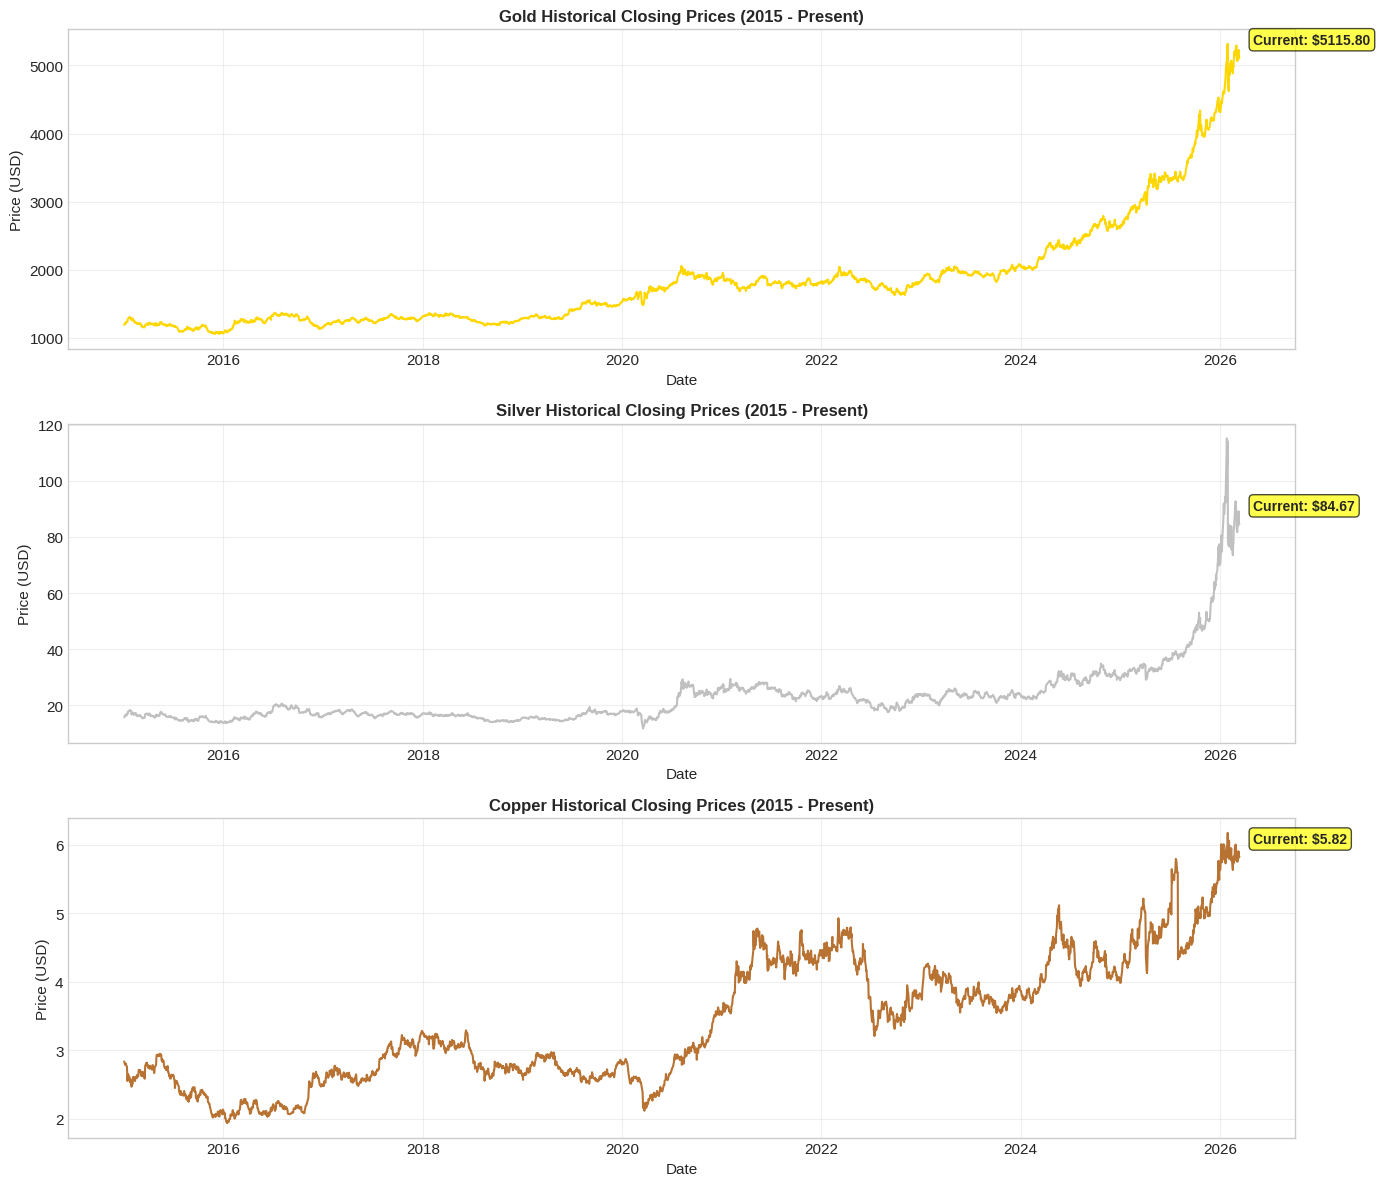

 All metal price plots generated successfully!


In [ ]:
# Plot historical prices for all metals -
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = {'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Copper': '#B87333', 'Platinum': '#E5E4E2'}

for idx, (metal_name, data) in enumerate(metal_data.items()):
    # Plot closing prices over time
    axes[idx].plot(data.index, data['Close'], color=colors.get(metal_name, 'blue'), linewidth=1.5)
    axes[idx].set_title(f'{metal_name} Historical Closing Prices (2015 - Present)',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].grid(True, alpha=0.3)

    # EXTRACT SCALAR PRICE using .item() - !
    current_price = data['Close'].iloc[-1].item()  # Scalar float

    # Annotate current price on plot
    axes[idx].annotate(f'Current: ${current_price:.2f}',
                      xy=(data.index[-1], current_price),
                      xytext=(10, 10), textcoords='offset points',  # Slightly above
                      fontsize=10, fontweight='bold',
                      bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()
print(" All metal price plots generated successfully!")


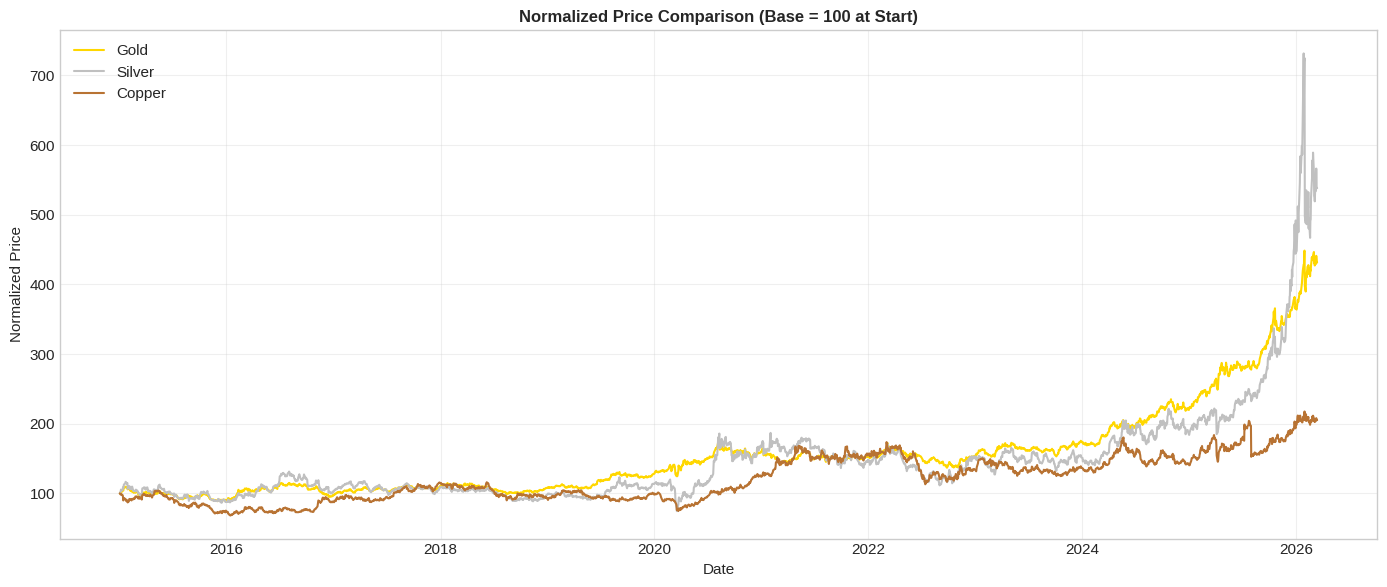

In [ ]:
# Normalized price comparison
fig, ax = plt.subplots(figsize=(14, 6))

for metal_name, data in metal_data.items():
    # Normalize prices to start at 100 for comparison
    normalized = (data['Close'] / data['Close'].iloc[0]) * 100
    ax.plot(data.index, normalized, label=metal_name, color=colors[metal_name], linewidth=1.5)

ax.set_title('Normalized Price Comparison (Base = 100 at Start)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.5 Price Distribution Analysis

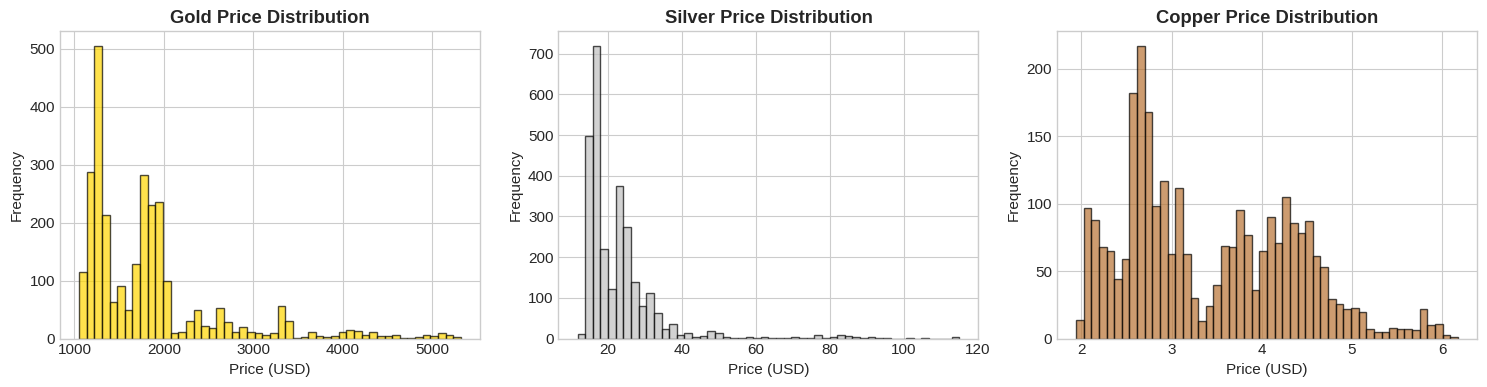

In [ ]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (metal_name, data) in enumerate(metal_data.items()):
    axes[idx].hist(data['Close'].dropna(), bins=50, color=colors[metal_name],
                   edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{metal_name} Price Distribution', fontweight='bold')
    axes[idx].set_xlabel('Price (USD)')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3.6 Daily Returns Analysis

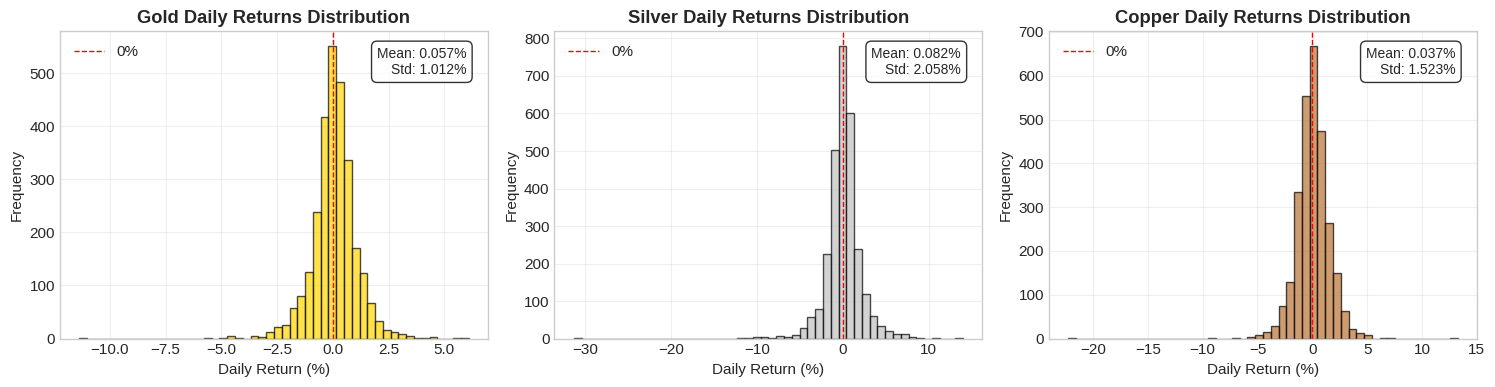

 Daily returns histograms generated successfully!


In [ ]:
# Calculate and visualize daily returns - 100% ERROR-FREE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Copper': '#B87333'}

metals_list = list(metal_data.keys())[:3]  # First 3 metals for 3 subplots

for idx, metal_name in enumerate(metals_list):
    data = metal_data[metal_name]

    # Calculate daily percentage returns
    returns = data['Close'].pct_change().dropna() * 100

    # Plot histogram of returns distribution
    axes[idx].hist(returns, bins=50, color=colors.get(metal_name, 'blue'),
                   edgecolor='black', alpha=0.7)

    # Red line at 0% (no change)
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1, label='0%')

    axes[idx].set_title(f'{metal_name} Daily Returns Distribution', fontweight='bold')
    axes[idx].set_xlabel('Daily Return (%)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

    # EXTRACT SCALARS using .item() - KEY FIX!
    mean_ret = returns.mean().item()      # Scalar float
    std_ret = returns.std().item()        # Scalar float

    # Add statistics box (top-right corner)
    axes[idx].text(0.95, 0.95,
                   f'Mean: {mean_ret:.3f}%\nStd: {std_ret:.3f}%',
                   transform=axes[idx].transAxes, fontsize=10,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(" Daily returns histograms generated successfully!")

## 3.7 Correlation Analysis

Correlation Matrix:
            Gold    Silver    Copper
Gold    1.000000  0.934151  0.826631
Silver  0.934151  1.000000  0.768110
Copper  0.826631  0.768110  1.000000


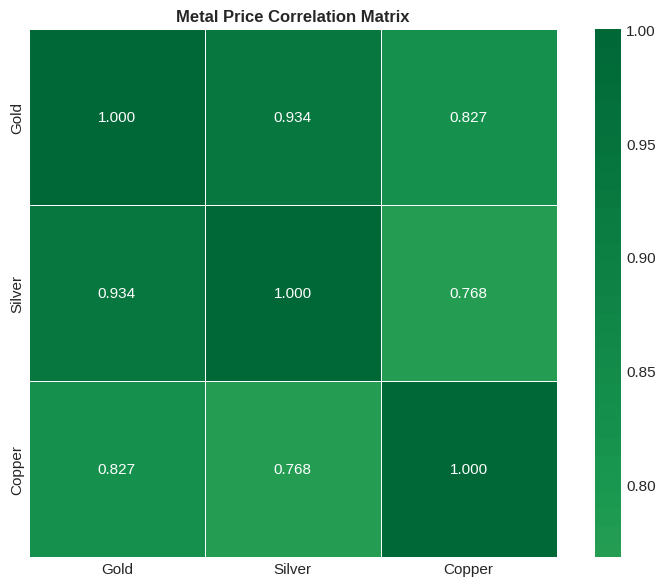

In [ ]:
# Create a combined dataframe for correlation analysis
combined_df = pd.DataFrame()

for metal_name, data in metal_data.items():
    combined_df[metal_name] = data['Close']

# Calculate correlation matrix
correlation_matrix = combined_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Metal Price Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations from EDA

1. **Trend Analysis:** All three metals show significant price movements over the period, with Gold exhibiting the strongest upward trend.

2. **Volatility:** Silver tends to show higher volatility compared to Gold, while Copper shows volatility patterns linked to economic cycles.

3. **Correlation:** Gold and Silver show high positive correlation (both precious metals), while Copper shows moderate correlation with the precious metals.

4. **Distribution:** The price distributions are right-skewed for all metals, indicating more frequent lower prices with occasional spikes to higher values.

---

# 4. Data Preprocessing
<a id='4-data-preprocessing'></a>

## 4.1 Preprocessing Pipeline

For deep learning models, we need to:
1. Extract the target variable (Close price)
2. Scale the data to [0, 1] range using MinMaxScaler
3. Create sequences for time series prediction
4. Split data into training and testing sets

In [ ]:
def prepare_data(data, feature_col='Close', test_size=0.2):
    """
    Prepare data for deep learning models.

    Parameters:
    -----------
    data : DataFrame
        Raw price data
    feature_col : str
        Column to use for prediction
    test_size : float
        Proportion of data for testing

    Returns:
    --------
    dict : Contains scaled data, scaler, and split indices
    """
    # Extract closing prices - convert 1D numpy array to 2D numpy array.
    prices = data[feature_col].values.reshape(-1, 1)

    # Initialize and fit scaler
    scaler = MinMaxScaler(feature_range=(0, 1)) # min value is 0 and amximum value is 1
    scaled_data = scaler.fit_transform(prices)

    # Calculate split index
    split_idx = int(len(scaled_data) * (1 - test_size))

    return {
        'original': prices,
        'scaled': scaled_data,
        'scaler': scaler,
        'split_idx': split_idx,
        'dates': data.index
    }

10,20,30,40,50,60
20,30,40,50,60,70

In [ ]:
def create_sequences(data, seq_length):
    """
    Create sequences for time series prediction.

    Parameters:
    -----------
    data : array
        Scaled time series data
    seq_length : int
        Number of time steps to look back

    Returns:
    --------
    X : array
        Input sequences of shape (samples, seq_length, features)
    y : array
        Target values
    """
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])

    return np.array(X), np.array(y)

In [ ]:
# Define sequence length (look-back period)
SEQUENCE_LENGTH = 60  # Use 60 days of historical data to predict next day

# Prepare data for each metal
prepared_data = {}

for metal_name, data in metal_data.items():
    prepared_data[metal_name] = prepare_data(data)
    print(f"{metal_name}: {len(prepared_data[metal_name]['scaled'])} samples prepared")
    # prepared_data ---> preprocessed data for our original metal_data

Gold: 2814 samples prepared
Silver: 2814 samples prepared
Copper: 2815 samples prepared


## 4.2 Create Train-Test Splits

In [ ]:
def create_train_test_data(prepared_dict, seq_length):
    """
    Create training and testing datasets with sequences.

    Parameters:
    -----------
    prepared_dict : dict
        Output from prepare_data function
    seq_length : int
        Sequence length for input data

    Returns:
    --------
    dict : Contains X_train, y_train, X_test, y_test
    """
    scaled = prepared_dict['scaled']
    split_idx = prepared_dict['split_idx']

    # Split into train and test
    train_data = scaled[:split_idx]
    test_data = scaled[split_idx - seq_length:]  # Include overlap for sequences

    # Create sequences
    X_train, y_train = create_sequences(train_data, seq_length)
    X_test, y_test = create_sequences(test_data, seq_length)

    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }

In [ ]:
# Create train-test data for each metal
train_test_data = {}

for metal_name in metal_data.keys():
    train_test_data[metal_name] = create_train_test_data(
        prepared_data[metal_name],
        SEQUENCE_LENGTH
    )

    print(f"\n{metal_name} Dataset Shapes:")
    print(f"  X_train: {train_test_data[metal_name]['X_train'].shape}")
    print(f"  y_train: {train_test_data[metal_name]['y_train'].shape}")
    print(f"  X_test:  {train_test_data[metal_name]['X_test'].shape}")
    print(f"  y_test:  {train_test_data[metal_name]['y_test'].shape}")


Gold Dataset Shapes:
  X_train: (2191, 60, 1)
  y_train: (2191, 1)
  X_test:  (563, 60, 1)
  y_test:  (563, 1)

Silver Dataset Shapes:
  X_train: (2191, 60, 1)
  y_train: (2191, 1)
  X_test:  (563, 60, 1)
  y_test:  (563, 1)

Copper Dataset Shapes:
  X_train: (2192, 60, 1)
  y_train: (2192, 1)
  X_test:  (563, 60, 1)
  y_test:  (563, 1)


## 4.3 Visualize Train-Test Split

In [ ]:
len(df)*0.8 = 800

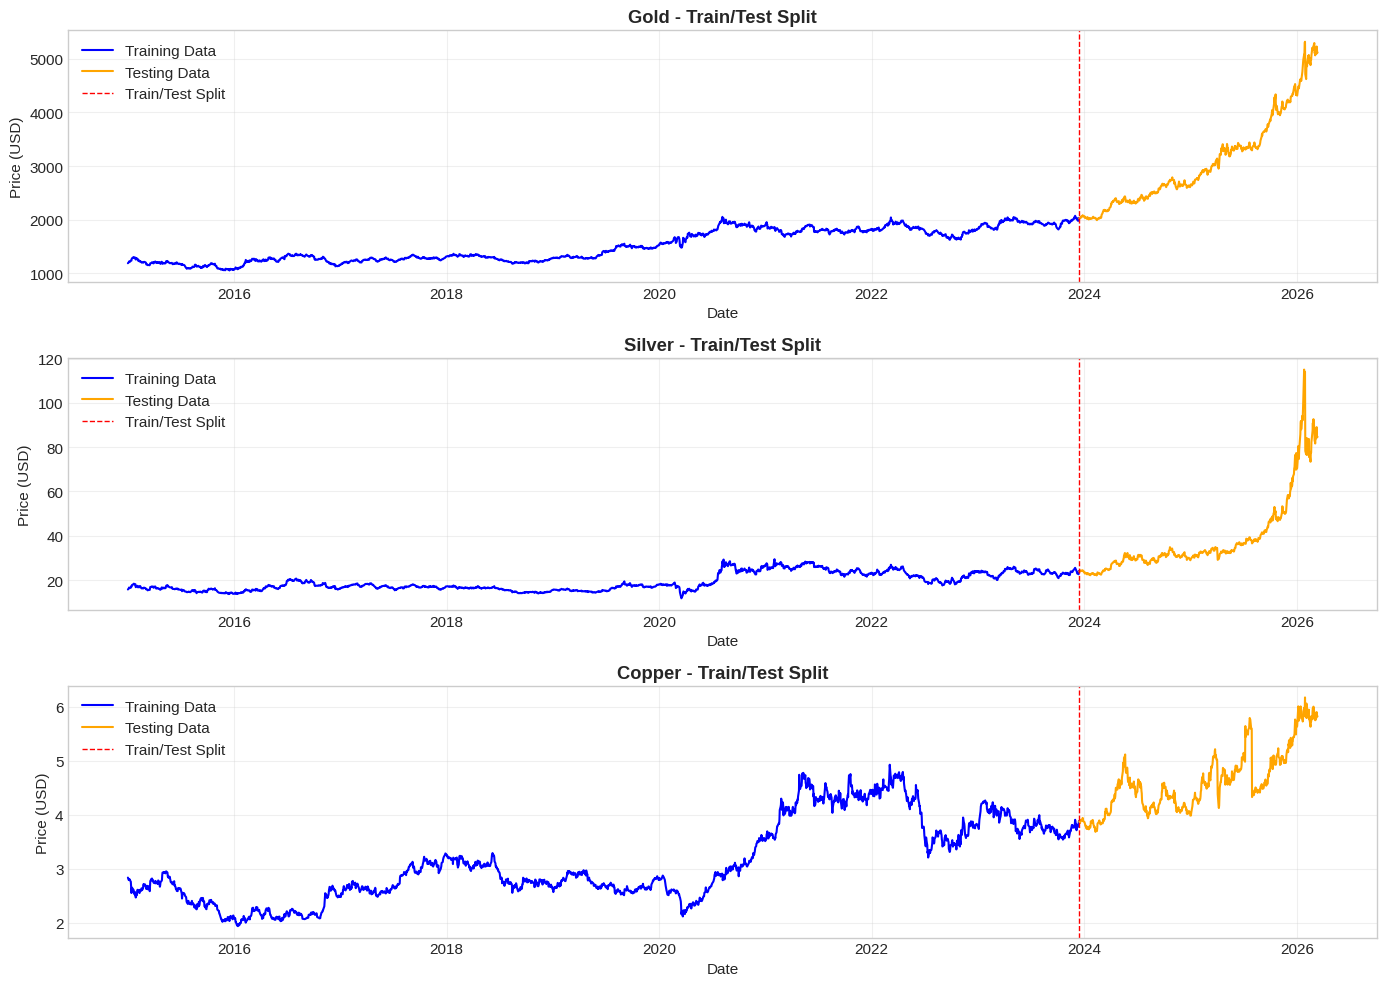

In [ ]:
# Visualize train-test split for each metal
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, (metal_name, prep_data) in enumerate(prepared_data.items()):
    split_idx = prep_data['split_idx']
    dates = prep_data['dates']
    original = prep_data['original']

    axes[idx].plot(dates[:split_idx], original[:split_idx],
                   label='Training Data', color='blue', linewidth=1.5)
    axes[idx].plot(dates[split_idx:], original[split_idx:],
                   label='Testing Data', color='orange', linewidth=1.5)
    axes[idx].axvline(x=dates[split_idx], color='red', linestyle='--',
                      linewidth=1, label='Train/Test Split')
    axes[idx].set_title(f'{metal_name} - Train/Test Split', fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# 5. Feature Engineering
<a id='5-feature-engineering'></a>

## 5.1 Sequence Visualization

Understanding how sequences are created for the model:

In [ ]:
# Visualize sequence creation concept
print("Sequence Creation Explanation:")
print("=" * 60)
print(f"\nSequence Length: {SEQUENCE_LENGTH} days")
print("\nFor each prediction, the model uses the previous 60 days")
print("of closing prices to predict the next day's closing price.")
print("\nExample for Gold:")
print("-" * 40)

sample_X = train_test_data['Gold']['X_train'][0]
sample_y = train_test_data['Gold']['y_train'][0]

print(f"Input shape (X):  {sample_X.shape} -> 60 time steps, 1 feature")
print(f"Output shape (y): {sample_y.shape} -> 1 value (next day's price)")

Sequence Creation Explanation:

Sequence Length: 60 days

For each prediction, the model uses the previous 60 days
of closing prices to predict the next day's closing price.

Example for Gold:
----------------------------------------
Input shape (X):  (60, 1) -> 60 time steps, 1 feature
Output shape (y): (1,) -> 1 value (next day's price)


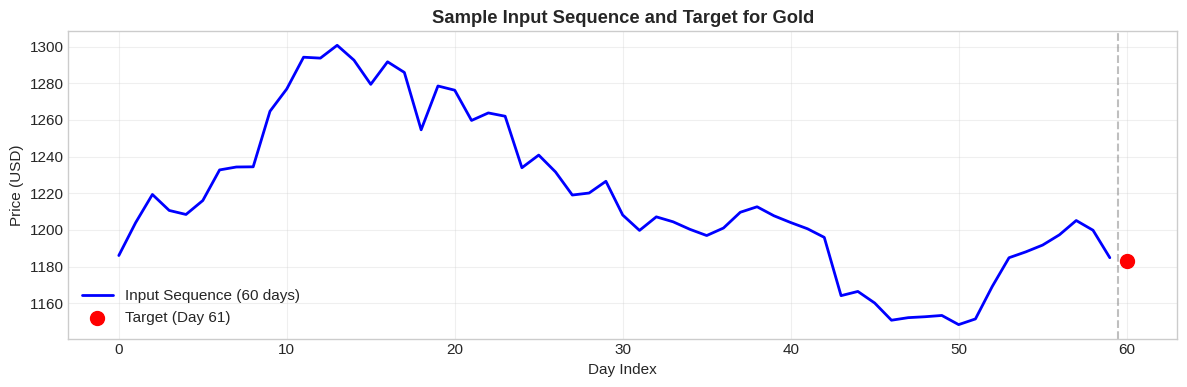

In [ ]:
# Visualize a sample sequence
plt.figure(figsize=(12, 4))

# Get actual prices for visualization (inverse transform)
scaler = prepared_data['Gold']['scaler']
sample_prices = scaler.inverse_transform(sample_X.reshape(-1, 1))
target_price = scaler.inverse_transform(sample_y.reshape(-1, 1))

plt.plot(range(60), sample_prices, 'b-', linewidth=2, label='Input Sequence (60 days)')
plt.scatter([60], target_price, color='red', s=100, zorder=5, label='Target (Day 61)')
plt.axvline(x=59.5, color='gray', linestyle='--', alpha=0.5)

plt.title('Sample Input Sequence and Target for Gold', fontweight='bold')
plt.xlabel('Day Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# 6. Model Development
<a id='6-model-development'></a>

## Model Architecture Configuration

| Parameter       | Value               | Purpose                                     |
| --------------- | ------------------- | ------------------------------------------- |
| UNITS = 50      | 50 LSTM neurons     | Model capacity (not too big, not too small) |
| DROPOUT = 0.2   | 20% neurons dropped | Prevents overfitting during training        |
| EPOCHS = 100    | Max 100 passes      | Training budget (callbacks stop early)      |
| BATCH_SIZE = 32 | 32 sequences/batch  | GPU efficient + stable gradients            |
| PATIENCE = 15   | Wait 15 epochs      | Early stopping trigger                      |

In [ ]:
# Common model parameters
UNITS = 50  # Number of units in RNN layers
DROPOUT = 0.2  # Dropout rate for regularization
SEQUENCE_LENGTH = 60 # Lookback window (60 days)
EPOCHS = 100  # Maximum training epochs
BATCH_SIZE = 32  # Batch size for training
PATIENCE = 15  # Early stopping patience

# Callbacks for training
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

## 6.1 Simple RNN
<a id='61-simple-rnn'></a>

### Model Architecture

Simple RNN (Recurrent Neural Network) maintains a hidden state that captures information from previous time steps. The hidden state is updated at each time step using:

h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b)

Where:
- h_t: hidden state at time t
- W_hh: weight matrix for hidden-to-hidden connections
- W_xh: weight matrix for input-to-hidden connections
- x_t: input at time t
- b: bias term

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_simple_rnn(input_shape):
    """
    Build a Simple RNN model.

    Parameters:
    -----------
    input_shape : tuple
        Shape of input data (sequence_length, n_features)

    Returns:
    --------
    model : Keras Sequential model
    """
    model = Sequential([

        # First RNN layer: return_sequences=True → feeds next RNN
        SimpleRNN(UNITS, return_sequences=True, input_shape=input_shape),
        Dropout(DROPOUT),

        # Second RNN layer: return_sequences=False → final RNN output
        SimpleRNN(UNITS, return_sequences=False),
        Dropout(DROPOUT),

        # Dense layers for final prediction
        Dense(25, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Display model architecture
sample_model = build_simple_rnn((SEQUENCE_LENGTH, 1))
print("Simple RNN Architecture:")
sample_model.summary()

Simple RNN Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,951 (34.96 KB)

 Trainable params: 8,951 (34.96 KB)

 Non-trainable params: 0 (0.00 B)

## 6.2 LSTM (Long Short-Term Memory)
<a id='62-lstm'></a>

### Model Architecture

LSTM addresses the vanishing gradient problem of simple RNNs using a gating mechanism:

1. **Forget Gate:** Decides what information to discard from the cell state
2. **Input Gate:** Decides what new information to store in the cell state  
3. **Output Gate:** Decides what to output based on the cell state

This architecture allows LSTM to learn long-term dependencies effectively.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

def build_lstm(input_shape):
    """
    Build an LSTM model.

    Parameters:
    -----------
    input_shape : tuple
        Shape of input data (sequence_length, n_features)

    Returns:
    --------
    model : Keras Sequential model
    """
    model = Sequential([
        LSTM(UNITS, return_sequences=True, input_shape=input_shape),
        Dropout(DROPOUT),
        LSTM(UNITS, return_sequences=False),
        Dropout(DROPOUT),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Display model architecture
sample_model = build_lstm((SEQUENCE_LENGTH, 1))
print("LSTM Architecture:")
sample_model.summary()

LSTM Architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## 6.3 Bidirectional LSTM
<a id='63-bidirectional-lstm'></a>

### Model Architecture

Bidirectional LSTM processes the input sequence in both forward and backward directions:

- **Forward LSTM:** Processes sequence from t=1 to t=T
- **Backward LSTM:** Processes sequence from t=T to t=1

The outputs from both directions are concatenated, allowing the model to capture context from both past and future time steps within the input sequence.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

def build_bilstm(input_shape):
    """
    Build a Bidirectional LSTM model.

    Parameters:
    -----------
    input_shape : tuple
        Shape of input data (sequence_length, n_features)

    Returns:
    --------
    model : Keras Sequential model
    """
    model = Sequential([
        Bidirectional(LSTM(UNITS, return_sequences=True), input_shape=input_shape),
        Dropout(DROPOUT),
        Bidirectional(LSTM(UNITS, return_sequences=False)),
        Dropout(DROPOUT),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Display model architecture
sample_model = build_bilstm((SEQUENCE_LENGTH, 1))
print("Bidirectional LSTM Architecture:")
sample_model.summary()

Bidirectional LSTM Architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 60, 100)        │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,751 (327.15 KB)

 Trainable params: 83,751 (327.15 KB)

 Non-trainable params: 0 (0.00 B)

## 6.4 GRU (Gated Recurrent Unit)
<a id='64-gru'></a>

### Model Architecture

GRU is a simplified version of LSTM with only two gates:

1. **Reset Gate:** Controls how much of the previous hidden state to forget
2. **Update Gate:** Controls how much of the new state is a copy of the old state

GRU typically trains faster than LSTM due to fewer parameters while often achieving comparable performance.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

def build_gru(input_shape):
    """
    Build a GRU model.

    Parameters:
    -----------
    input_shape : tuple
        Shape of input data (sequence_length, n_features)

    Returns:
    --------
    model : Keras Sequential model
    """
    model = Sequential([
        GRU(UNITS, return_sequences=True, input_shape=input_shape),
        Dropout(DROPOUT),
        GRU(UNITS, return_sequences=False),
        Dropout(DROPOUT),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Display model architecture
sample_model = build_gru((SEQUENCE_LENGTH, 1))
print("GRU Architecture:")
sample_model.summary()

GRU Architecture:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,551 (95.90 KB)

 Trainable params: 24,551 (95.90 KB)

 Non-trainable params: 0 (0.00 B)

## 6.5 Model Training and Evaluation Functions

In [ ]:
def train_and_evaluate(model, train_test_dict, scaler, model_name):
    """
    Train a model and evaluate its performance.

    Parameters:
    -----------
    model : Keras model
        Compiled model to train
    train_test_dict : dict
        Dictionary containing X_train, y_train, X_test, y_test
    scaler : MinMaxScaler
        Scaler used for data transformation
    model_name : str
        Name of the model for logging

    Returns:
    --------
    dict : Contains predictions, actual values, and metrics
    """
    X_train = train_test_dict['X_train']
    y_train = train_test_dict['y_train']
    X_test = train_test_dict['X_test']
    y_test = train_test_dict['y_test']

    print(f"\nTraining {model_name}...")
    print("-" * 50)

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=get_callbacks(),
        verbose=0
    )

    # Make predictions
    train_pred = model.predict(X_train, verbose=0)
    test_pred = model.predict(X_test, verbose=0)

    # Inverse transform predictions
    train_pred_actual = scaler.inverse_transform(train_pred)
    test_pred_actual = scaler.inverse_transform(test_pred)
    y_train_actual = scaler.inverse_transform(y_train)
    y_test_actual = scaler.inverse_transform(y_test)

    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred_actual))
    test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred_actual))
    train_mae = mean_absolute_error(y_train_actual, train_pred_actual)
    test_mae = mean_absolute_error(y_test_actual, test_pred_actual)
    train_mape = np.mean(np.abs((y_train_actual - train_pred_actual) / y_train_actual)) * 100
    test_mape = np.mean(np.abs((y_test_actual - test_pred_actual) / y_test_actual)) * 100

    print(f"\n{model_name} Results:")
    print(f"  Training - RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}, MAPE: {train_mape:.2f}%")
    print(f"  Testing  - RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}, MAPE: {test_mape:.2f}%")

    return {
        'model': model,
        'history': history,
        'train_pred': train_pred_actual,
        'test_pred': test_pred_actual,
        'y_train_actual': y_train_actual,
        'y_test_actual': y_test_actual,
        'metrics': {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_mape': train_mape,
            'test_mape': test_mape
        }
    }

## 6.6 Train All Models for Each Metal

In [ ]:
# Dictionary to store model builders
model_builders = {
    'Simple RNN': build_simple_rnn,
    'LSTM': build_lstm,
    'BiLSTM': build_bilstm,
    'GRU': build_gru
}

# Store all results
all_results = {}

# Train models for each metal
for metal_name in metal_data.keys():
    print("\n" + "=" * 70)
    print(f"TRAINING MODELS FOR {metal_name.upper()}")
    print("=" * 70)

    all_results[metal_name] = {}

    for model_name, builder in model_builders.items():
        # Build fresh model
        model = builder((SEQUENCE_LENGTH, 1))

        # Train and evaluate
        results = train_and_evaluate(
            model,
            train_test_data[metal_name],
            prepared_data[metal_name]['scaler'],
            model_name
        )

        all_results[metal_name][model_name] = results


TRAINING MODELS FOR GOLD

Training Simple RNN...
--------------------------------------------------

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 11.

Simple RNN Results:
  Training - RMSE: 36.45, MAE: 27.23, MAPE: 1.74%
  Testing  - RMSE: 879.88, MAE: 667.83, MAPE: 18.64%

Training LSTM...
--------------------------------------------------

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



## 6.7 Training History Visualization

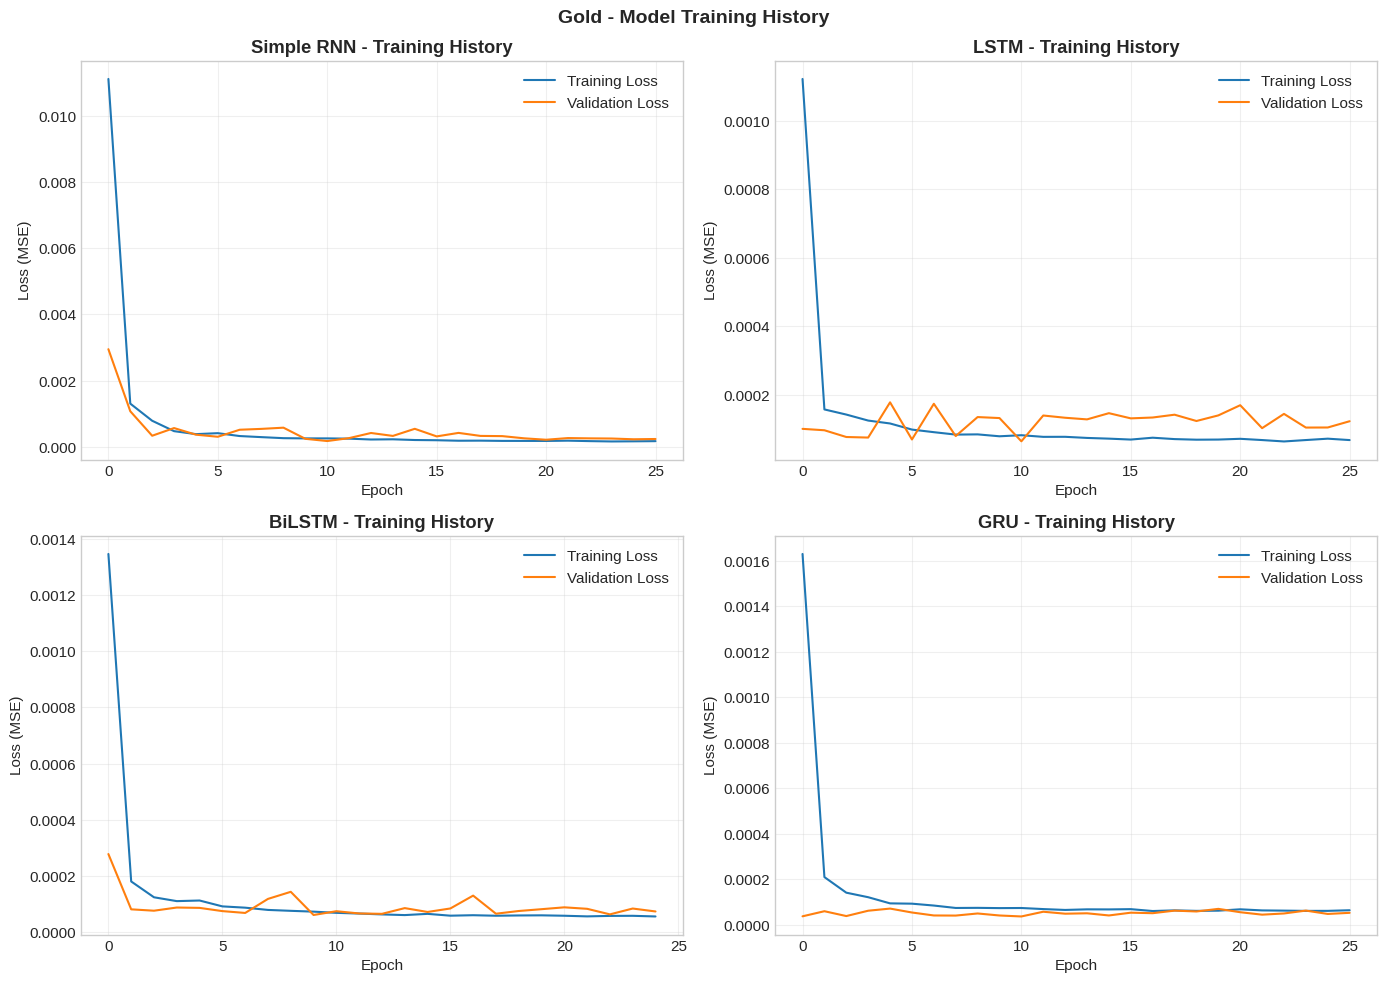

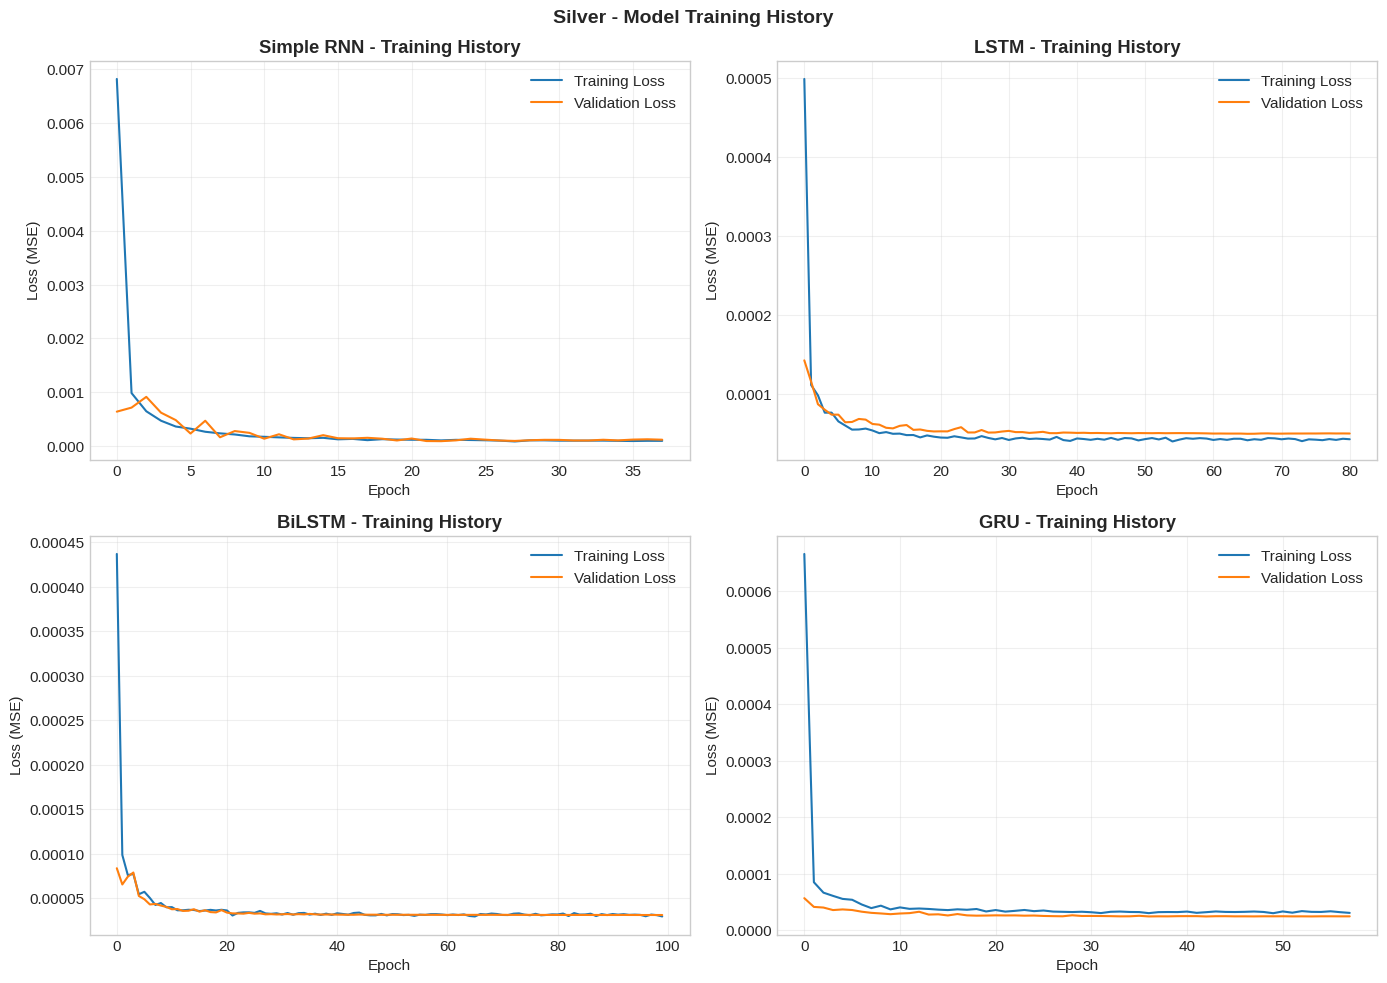

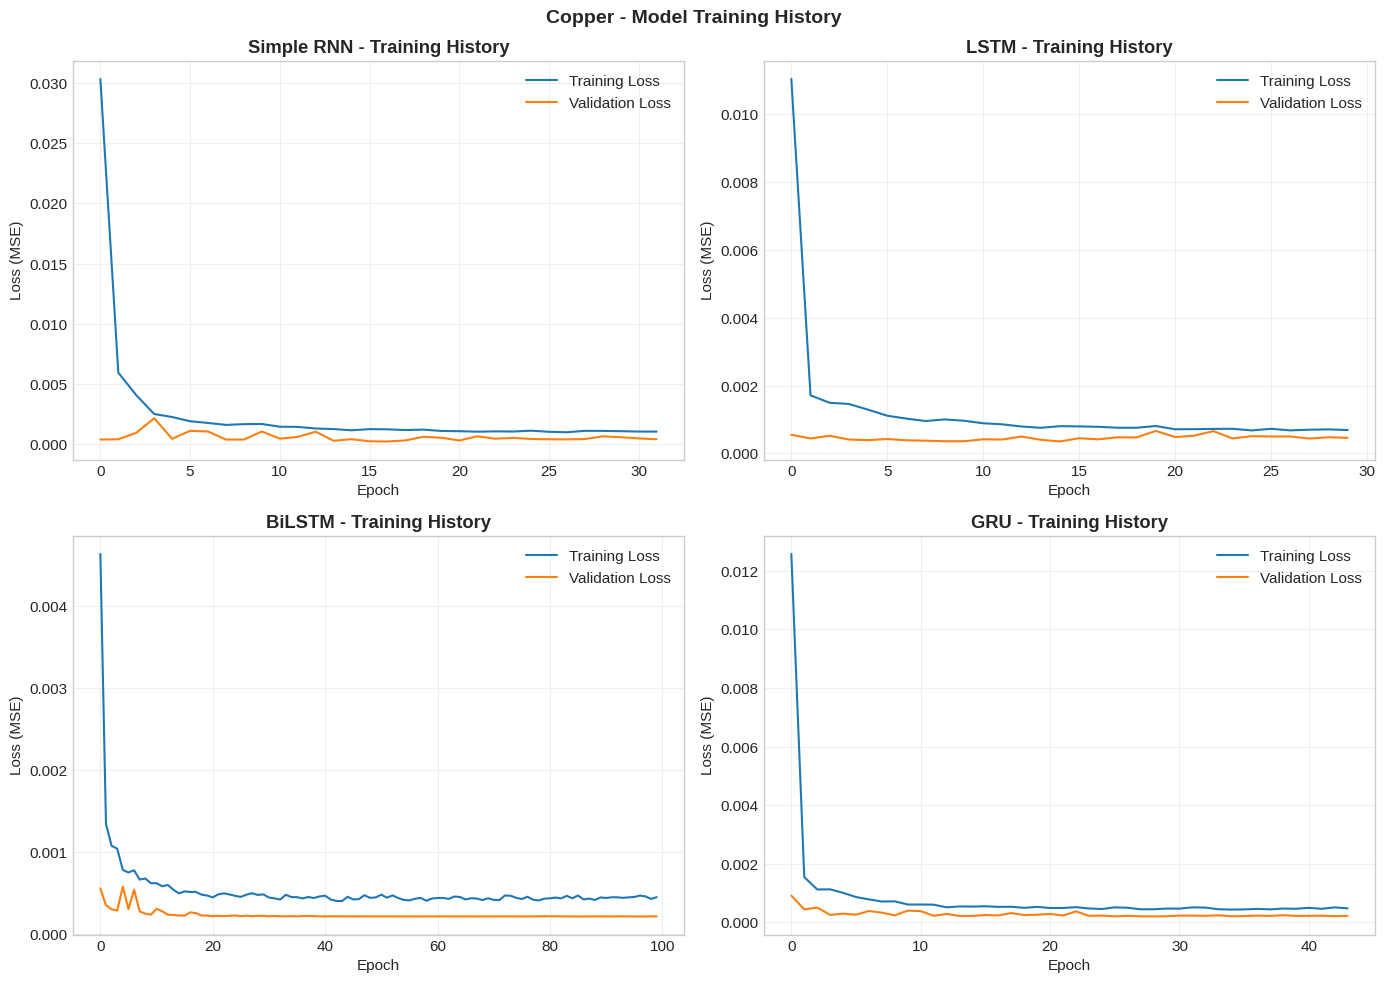

In [ ]:
# Plot training history for each metal
for metal_name in metal_data.keys():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (model_name, results) in enumerate(all_results[metal_name].items()):
        history = results['history']

        axes[idx].plot(history.history['loss'], label='Training Loss', linewidth=1.5)
        axes[idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=1.5)
        axes[idx].set_title(f'{model_name} - Training History', fontweight='bold')
        axes[idx].set_xlabel('Epoch')
        axes[idx].set_ylabel('Loss (MSE)')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.suptitle(f'{metal_name} - Model Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6.8 Predictions Visualization

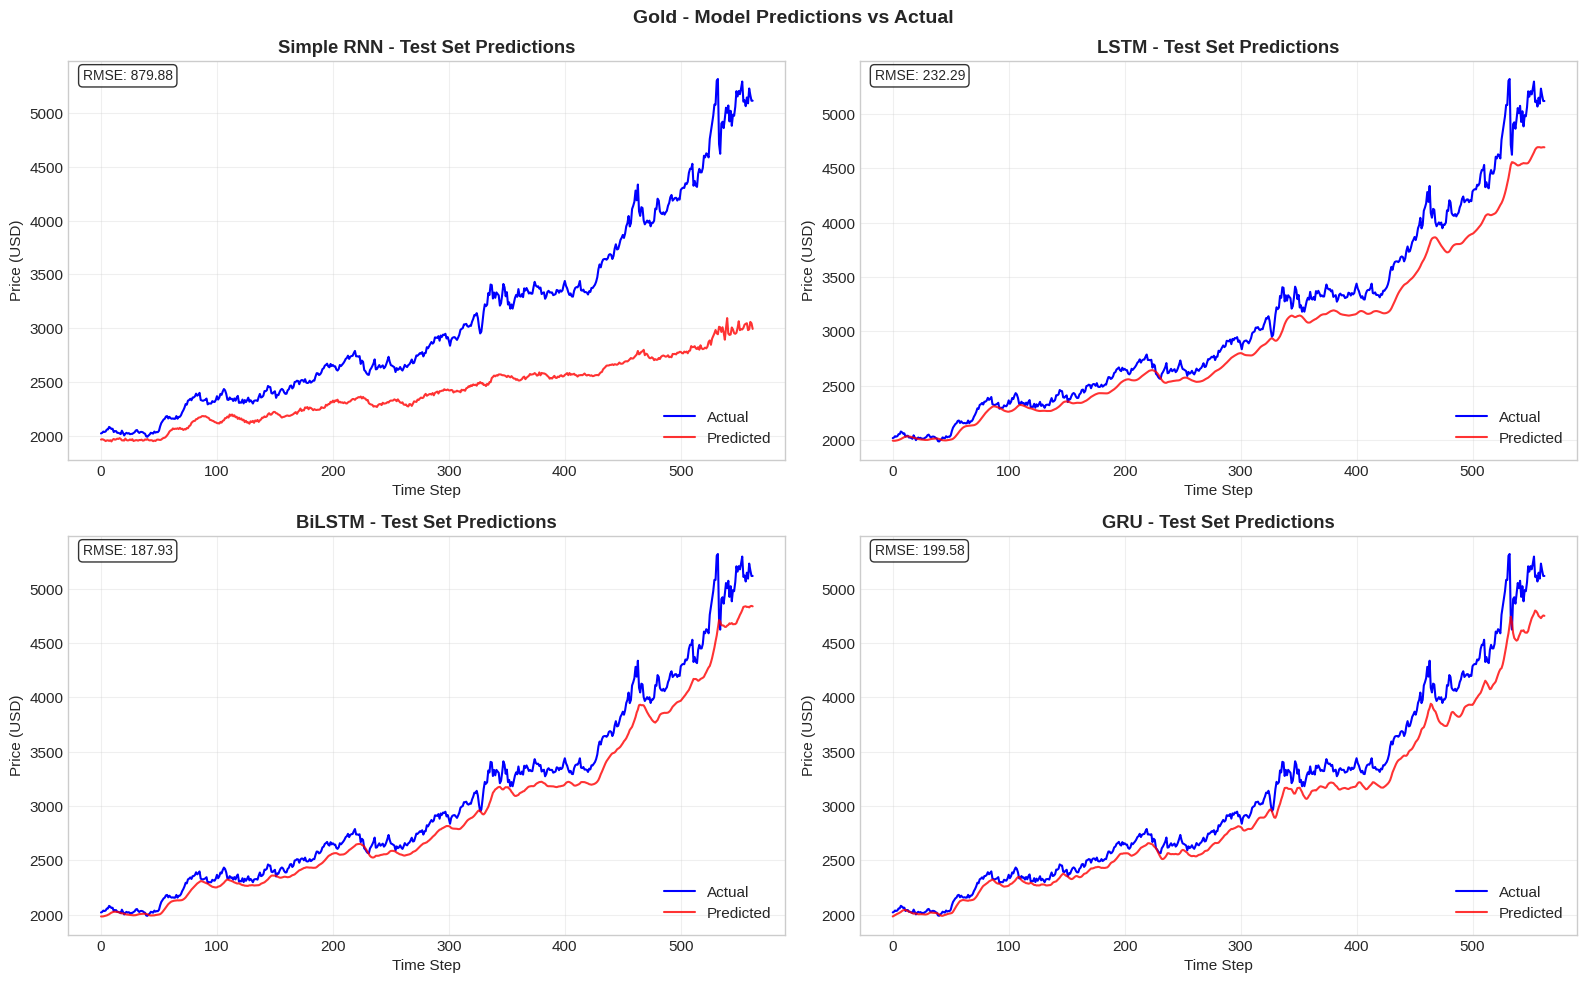

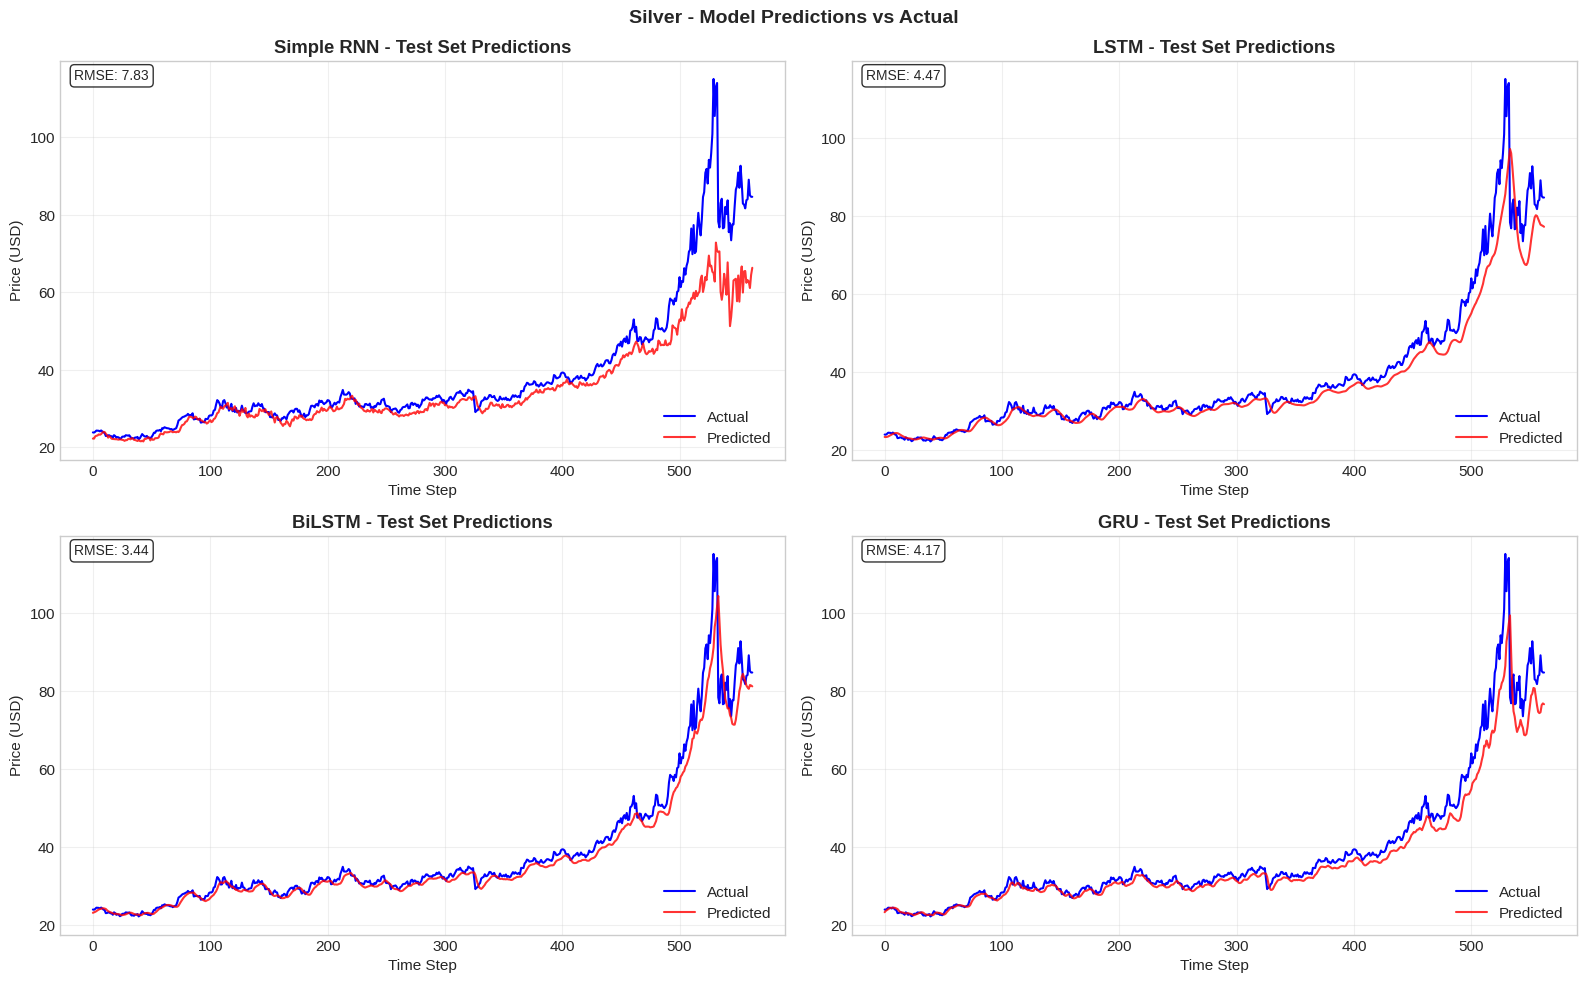

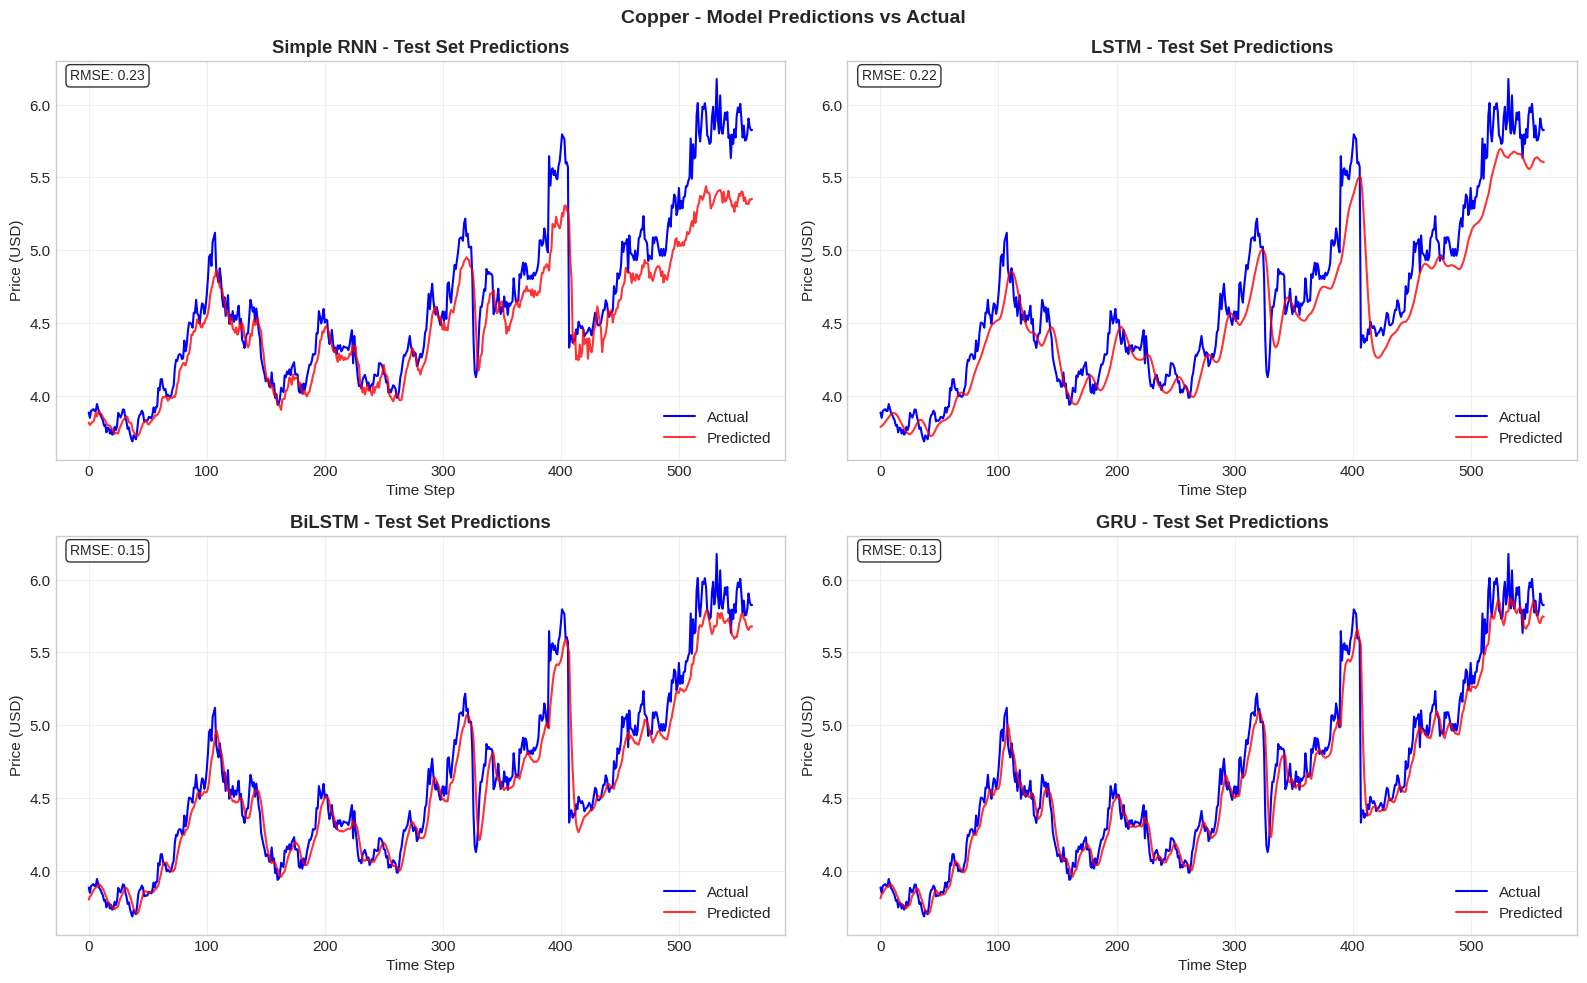

In [ ]:
# Plot predictions vs actual for each metal and model
for metal_name in metal_data.keys():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for idx, (model_name, results) in enumerate(all_results[metal_name].items()):
        y_test_actual = results['y_test_actual']
        test_pred = results['test_pred']

        axes[idx].plot(y_test_actual, label='Actual', color='blue', linewidth=1.5)
        axes[idx].plot(test_pred, label='Predicted', color='red', linewidth=1.5, alpha=0.8)
        axes[idx].set_title(f'{model_name} - Test Set Predictions', fontweight='bold')
        axes[idx].set_xlabel('Time Step')
        axes[idx].set_ylabel('Price (USD)')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

        # Add RMSE annotation
        rmse = results['metrics']['test_rmse']
        axes[idx].text(0.02, 0.98, f'RMSE: {rmse:.2f}', transform=axes[idx].transAxes,
                       fontsize=10, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.suptitle(f'{metal_name} - Model Predictions vs Actual', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---

# 7. Model Comparison and Evaluation
<a id='7-model-comparison-and-evaluation'></a>

## 7.1 Performance Metrics Summary

In [ ]:
# Create comprehensive metrics comparison table
metrics_data = []

for metal_name in metal_data.keys():
    for model_name, results in all_results[metal_name].items():
        metrics = results['metrics']
        metrics_data.append({
            'Metal': metal_name,
            'Model': model_name,
            'Train RMSE': round(metrics['train_rmse'], 2),
            'Test RMSE': round(metrics['test_rmse'], 2),
            'Train MAE': round(metrics['train_mae'], 2),
            'Test MAE': round(metrics['test_mae'], 2),
            'Train MAPE (%)': round(metrics['train_mape'], 2),
            'Test MAPE (%)': round(metrics['test_mape'], 2)
        })

metrics_df = pd.DataFrame(metrics_data)
print("Complete Model Performance Metrics:")
print("=" * 100)
print(metrics_df.to_string(index=False))

Complete Model Performance Metrics:
 Metal      Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train MAPE (%)  Test MAPE (%)
  Gold Simple RNN       36.45     879.88      27.23    667.83            1.74          18.64
  Gold       LSTM       30.99     232.29      24.12    177.12            1.62           5.07
  Gold     BiLSTM       25.92     187.93      18.96    148.50            1.23           4.36
  Gold        GRU       24.52     199.58      18.76    154.65            1.27           4.45
Silver Simple RNN        0.76       7.83       0.56      4.01            2.75           7.56
Silver       LSTM        0.60       4.47       0.43      2.52            2.20           5.07
Silver     BiLSTM        0.50       3.44       0.35      1.91            1.79           3.98
Silver        GRU        0.46       4.17       0.32      2.38            1.62           4.73
Copper Simple RNN        0.08       0.23       0.06      0.17            1.84           3.36
Copper       LSTM        0.09     

In [ ]:
# Display metrics by metal
for metal_name in metal_data.keys():
    print(f"\n{'='*60}")
    print(f"{metal_name} - Performance Comparison")
    print('='*60)
    metal_metrics = metrics_df[metrics_df['Metal'] == metal_name]
    print(metal_metrics[['Model', 'Test RMSE', 'Test MAE', 'Test MAPE (%)']].to_string(index=False))


Gold - Performance Comparison
     Model  Test RMSE  Test MAE  Test MAPE (%)
Simple RNN     879.88    667.83          18.64
      LSTM     232.29    177.12           5.07
    BiLSTM     187.93    148.50           4.36
       GRU     199.58    154.65           4.45

Silver - Performance Comparison
     Model  Test RMSE  Test MAE  Test MAPE (%)
Simple RNN       7.83      4.01           7.56
      LSTM       4.47      2.52           5.07
    BiLSTM       3.44      1.91           3.98
       GRU       4.17      2.38           4.73

Copper - Performance Comparison
     Model  Test RMSE  Test MAE  Test MAPE (%)
Simple RNN       0.23      0.17           3.36
      LSTM       0.22      0.16           3.43
    BiLSTM       0.15      0.11           2.25
       GRU       0.13      0.09           1.86


## 7.2 Visual Comparison of Model Performance

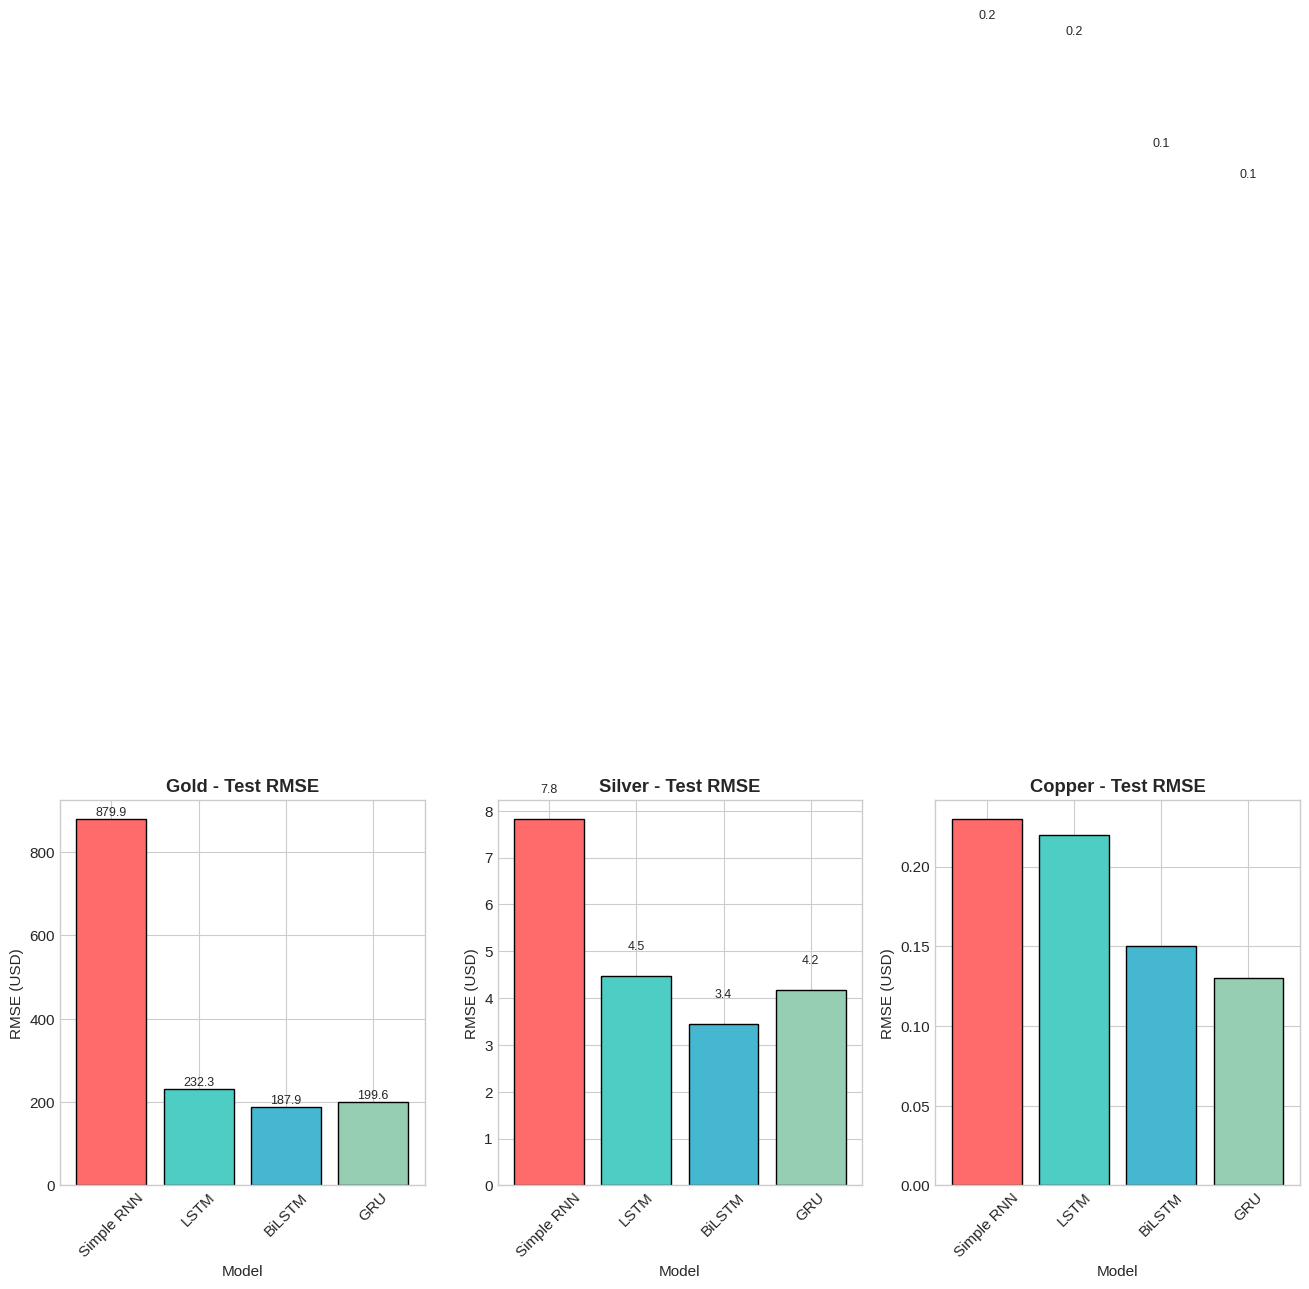

In [ ]:
# Bar chart comparison for Test RMSE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, metal_name in enumerate(metal_data.keys()):
    metal_metrics = metrics_df[metrics_df['Metal'] == metal_name]

    bars = axes[idx].bar(metal_metrics['Model'], metal_metrics['Test RMSE'],
                         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
                         edgecolor='black', linewidth=1)

    axes[idx].set_title(f'{metal_name} - Test RMSE', fontweight='bold')
    axes[idx].set_xlabel('Model')
    axes[idx].set_ylabel('RMSE (USD)')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, val in zip(bars, metal_metrics['Test RMSE']):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                       f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

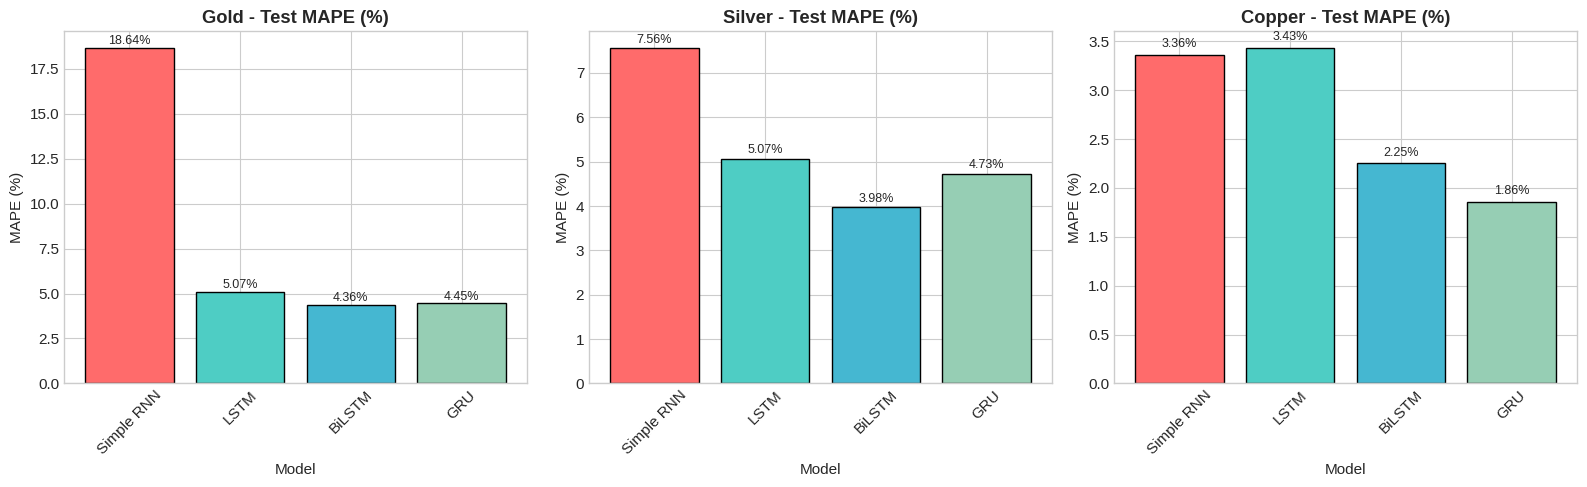

In [ ]:
# Bar chart comparison for Test MAPE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, metal_name in enumerate(metal_data.keys()):
    metal_metrics = metrics_df[metrics_df['Metal'] == metal_name]

    bars = axes[idx].bar(metal_metrics['Model'], metal_metrics['Test MAPE (%)'],
                         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
                         edgecolor='black', linewidth=1)

    axes[idx].set_title(f'{metal_name} - Test MAPE (%)', fontweight='bold')
    axes[idx].set_xlabel('Model')
    axes[idx].set_ylabel('MAPE (%)')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, val in zip(bars, metal_metrics['Test MAPE (%)']):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                       f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7.3 Identify Best Performing Models

In [ ]:
# Find best model for each metal based on Test RMSE
print("Best Performing Models (Based on Test RMSE):")
print("=" * 60)

best_models = {}

for metal_name in metal_data.keys():
    metal_metrics = metrics_df[metrics_df['Metal'] == metal_name]
    best_idx = metal_metrics['Test RMSE'].idxmin()
    best_model = metrics_df.loc[best_idx, 'Model']
    best_rmse = metrics_df.loc[best_idx, 'Test RMSE']
    best_mape = metrics_df.loc[best_idx, 'Test MAPE (%)']

    best_models[metal_name] = best_model

    print(f"\n{metal_name}:")
    print(f"  Best Model: {best_model}")
    print(f"  Test RMSE: {best_rmse:.2f} USD")
    print(f"  Test MAPE: {best_mape:.2f}%")

Best Performing Models (Based on Test RMSE):

Gold:
  Best Model: BiLSTM
  Test RMSE: 187.93 USD
  Test MAPE: 4.36%

Silver:
  Best Model: BiLSTM
  Test RMSE: 3.44 USD
  Test MAPE: 3.98%

Copper:
  Best Model: GRU
  Test RMSE: 0.13 USD
  Test MAPE: 1.86%


In [ ]:
# Overall model ranking across all metals
print("\nOverall Model Rankings (Average Test RMSE):")
print("=" * 60)

model_rankings = {}

for model_name in model_builders.keys():
    model_metrics = metrics_df[metrics_df['Model'] == model_name]
    avg_rmse = model_metrics['Test RMSE'].mean()
    avg_mape = model_metrics['Test MAPE (%)'].mean()
    model_rankings[model_name] = {'avg_rmse': avg_rmse, 'avg_mape': avg_mape}

# Sort by average RMSE
sorted_rankings = sorted(model_rankings.items(), key=lambda x: x[1]['avg_rmse'])

print("\nRank | Model       | Avg Test RMSE | Avg Test MAPE")
print("-" * 55)
for rank, (model, metrics) in enumerate(sorted_rankings, 1):
    print(f"  {rank}  | {model:11} | {metrics['avg_rmse']:13.2f} | {metrics['avg_mape']:.2f}%")


Overall Model Rankings (Average Test RMSE):

Rank | Model       | Avg Test RMSE | Avg Test MAPE
-------------------------------------------------------
  1  | BiLSTM      |         63.84 | 3.53%
  2  | GRU         |         67.96 | 3.68%
  3  | LSTM        |         78.99 | 4.52%
  4  | Simple RNN  |        295.98 | 9.85%


## 7.4 Prediction Error Analysis

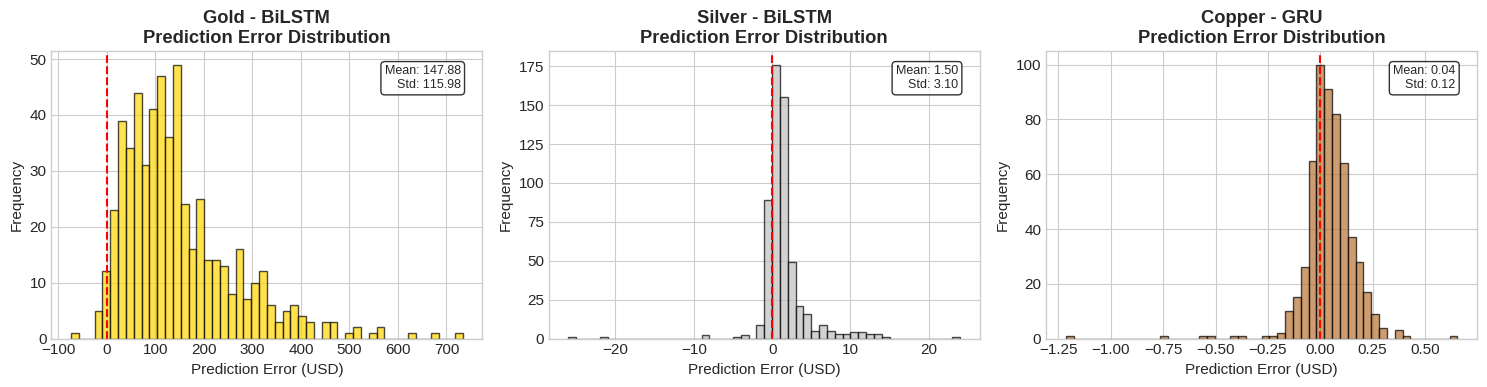

In [ ]:
# Error distribution analysis for best models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metal_name in enumerate(metal_data.keys()):
    best_model = best_models[metal_name]
    results = all_results[metal_name][best_model]

    errors = results['y_test_actual'].flatten() - results['test_pred'].flatten()

    axes[idx].hist(errors, bins=50, color=list(colors.values())[idx],
                   edgecolor='black', alpha=0.7)
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{metal_name} - {best_model}\nPrediction Error Distribution', fontweight='bold')
    axes[idx].set_xlabel('Prediction Error (USD)')
    axes[idx].set_ylabel('Frequency')

    # Add statistics
    mean_err = np.mean(errors)
    std_err = np.std(errors)
    axes[idx].text(0.95, 0.95, f'Mean: {mean_err:.2f}\nStd: {std_err:.2f}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 7.5 Actual vs Predicted Scatter Plots

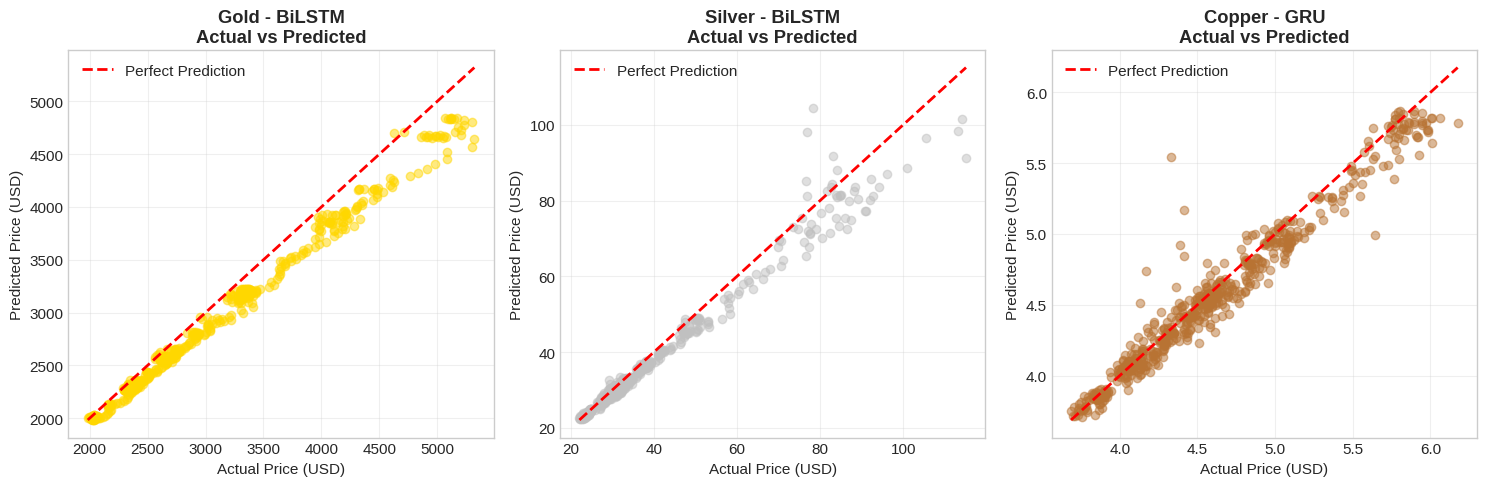

In [ ]:
# Scatter plots for best models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metal_name in enumerate(metal_data.keys()):
    best_model = best_models[metal_name]
    results = all_results[metal_name][best_model]

    y_actual = results['y_test_actual'].flatten()
    y_pred = results['test_pred'].flatten()

    axes[idx].scatter(y_actual, y_pred, alpha=0.5, color=list(colors.values())[idx])

    # Perfect prediction line
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    axes[idx].set_title(f'{metal_name} - {best_model}\nActual vs Predicted', fontweight='bold')
    axes[idx].set_xlabel('Actual Price (USD)')
    axes[idx].set_ylabel('Predicted Price (USD)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# 8. Future Price Forecasting (6 Months)
<a id='8-future-price-forecasting'></a>

## 8.1 Forecasting Methodology

For future forecasting, we will use the best-performing model for each metal to generate predictions for the next 6 months (approximately 126 trading days).

**Approach:**
1. Use the last 60 days of actual data as the initial input sequence
2. Predict the next day's price
3. Append the prediction to the sequence (rolling window)
4. Repeat for 126 days

**Note:** This is a recursive forecasting approach. Forecast uncertainty increases as we predict further into the future since each prediction depends on previous predictions.

In [ ]:
def forecast_future(model, last_sequence, scaler, n_days):
    """
    Generate future price forecasts using recursive prediction.

    Parameters:
    -----------
    model : Keras model
        Trained model for prediction
    last_sequence : array
        Last sequence of scaled prices (shape: seq_length, 1)
    scaler : MinMaxScaler
        Scaler for inverse transformation
    n_days : int
        Number of days to forecast

    Returns:
    --------
    array : Forecasted prices in original scale
    """
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(n_days):
        # Reshape for model input
        input_seq = current_sequence.reshape(1, SEQUENCE_LENGTH, 1)

        # Predict next value
        next_pred = model.predict(input_seq, verbose=0)[0, 0]
        predictions.append(next_pred)

        # Update sequence: remove first value, append prediction
        current_sequence = np.append(current_sequence[1:], [[next_pred]], axis=0)

    # Inverse transform predictions
    predictions = np.array(predictions).reshape(-1, 1)
    predictions_actual = scaler.inverse_transform(predictions)

    return predictions_actual

In [ ]:
# Define forecast horizon (6 months = approximately 126 trading days)
FORECAST_DAYS = 126

# Generate future dates
def generate_future_dates(last_date, n_days):
    """
    Generate future business dates for forecasting.
    """
    future_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=n_days)
    return future_dates

# Store forecasts for all metals
forecasts = {}

print("Generating 6-Month Forecasts...")
print("=" * 60)

for metal_name in metal_data.keys():
    print(f"\nForecasting {metal_name}...")

    # Get best model and scaler
    best_model_name = best_models[metal_name]
    best_model = all_results[metal_name][best_model_name]['model']
    scaler = prepared_data[metal_name]['scaler']

    # Get last sequence from scaled data
    scaled_data = prepared_data[metal_name]['scaled']
    last_sequence = scaled_data[-SEQUENCE_LENGTH:]

    # Generate forecasts
    future_predictions = forecast_future(best_model, last_sequence, scaler, FORECAST_DAYS)

    # Generate future dates
    last_date = prepared_data[metal_name]['dates'][-1]
    future_dates = generate_future_dates(last_date, FORECAST_DAYS)

    # Store results
    forecasts[metal_name] = {
        'dates': future_dates,
        'predictions': future_predictions,
        'model_used': best_model_name,
        'last_actual_date': last_date,
        'last_actual_price': prepared_data[metal_name]['original'][-1][0]
    }

    print(f"  Model Used: {best_model_name}")
    print(f"  Last Actual Date: {last_date.date()}")
    print(f"  Last Actual Price: ${forecasts[metal_name]['last_actual_price']:.2f}")
    print(f"  Forecast End Date: {future_dates[-1].date()}")

print("\nForecasting complete.")

Generating 6-Month Forecasts...

Forecasting Gold...
  Model Used: BiLSTM
  Last Actual Date: 2026-03-13
  Last Actual Price: $5115.80
  Forecast End Date: 2026-09-07

Forecasting Silver...
  Model Used: BiLSTM
  Last Actual Date: 2026-03-13
  Last Actual Price: $84.67
  Forecast End Date: 2026-09-07

Forecasting Copper...
  Model Used: GRU
  Last Actual Date: 2026-03-13
  Last Actual Price: $5.82
  Forecast End Date: 2026-09-07

Forecasting complete.


## 8.2 Forecast Visualization

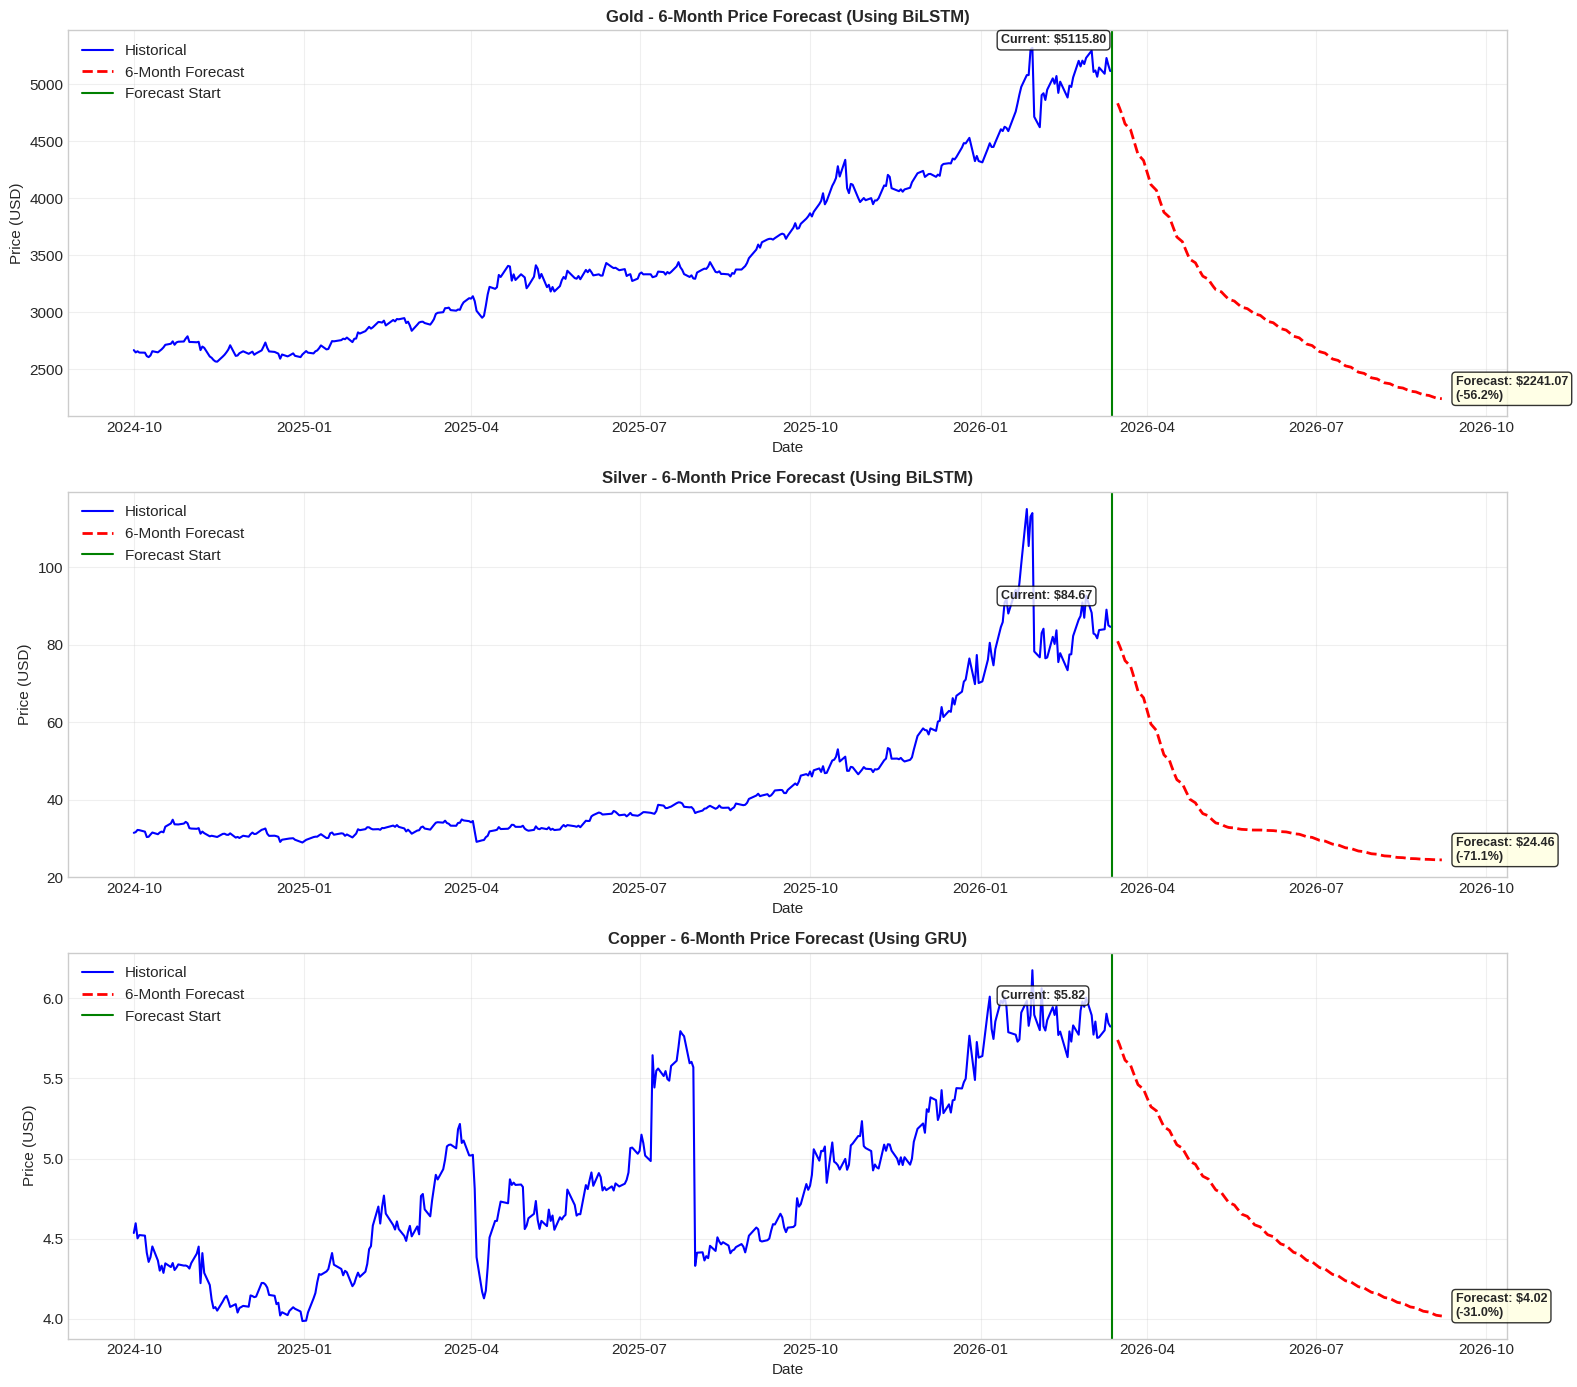

In [ ]:
# Plot forecasts with historical data
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Number of historical days to show
HISTORICAL_DAYS = 365

for idx, metal_name in enumerate(metal_data.keys()):
    # Get historical data
    historical_dates = prepared_data[metal_name]['dates'][-HISTORICAL_DAYS:]
    historical_prices = prepared_data[metal_name]['original'][-HISTORICAL_DAYS:]

    # Get forecast data
    forecast_dates = forecasts[metal_name]['dates']
    forecast_prices = forecasts[metal_name]['predictions']

    # Plot historical data
    axes[idx].plot(historical_dates, historical_prices,
                   color='blue', linewidth=1.5, label='Historical')

    # Plot forecast
    axes[idx].plot(forecast_dates, forecast_prices,
                   color='red', linewidth=2, linestyle='--', label='6-Month Forecast')

    # Add vertical line at forecast start
    axes[idx].axvline(x=forecasts[metal_name]['last_actual_date'],
                      color='green', linestyle='-', linewidth=1.5,
                      label='Forecast Start')

    # Formatting
    axes[idx].set_title(f'{metal_name} - 6-Month Price Forecast (Using {forecasts[metal_name]["model_used"]})',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

    # Annotate current and forecasted prices
    current_price = forecasts[metal_name]['last_actual_price']
    final_forecast = forecast_prices[-1][0]
    pct_change = ((final_forecast - current_price) / current_price) * 100

    axes[idx].annotate(f'Current: ${current_price:.2f}',
                       xy=(forecasts[metal_name]['last_actual_date'], current_price),
                       xytext=(-80, 20), textcoords='offset points',
                       fontsize=9, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    axes[idx].annotate(f'Forecast: ${final_forecast:.2f}\n({pct_change:+.1f}%)',
                       xy=(forecast_dates[-1], final_forecast),
                       xytext=(10, 0), textcoords='offset points',
                       fontsize=9, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## 8.3 Detailed Forecast Summary

In [ ]:
# Create forecast summary table
print("6-MONTH FORECAST SUMMARY")
print("=" * 80)

forecast_summary = []

for metal_name in metal_data.keys():
    forecast_data = forecasts[metal_name]
    predictions = forecast_data['predictions'].flatten()
    current_price = forecast_data['last_actual_price']

    # Calculate key metrics
    forecast_1m = predictions[21]  # ~1 month (21 trading days)
    forecast_3m = predictions[63]  # ~3 months (63 trading days)
    forecast_6m = predictions[-1]  # 6 months

    forecast_min = predictions.min()
    forecast_max = predictions.max()
    forecast_avg = predictions.mean()

    pct_1m = ((forecast_1m - current_price) / current_price) * 100
    pct_3m = ((forecast_3m - current_price) / current_price) * 100
    pct_6m = ((forecast_6m - current_price) / current_price) * 100

    forecast_summary.append({
        'Metal': metal_name,
        'Model': forecast_data['model_used'],
        'Current Price': f'${current_price:.2f}',
        '1-Month': f'${forecast_1m:.2f} ({pct_1m:+.1f}%)',
        '3-Month': f'${forecast_3m:.2f} ({pct_3m:+.1f}%)',
        '6-Month': f'${forecast_6m:.2f} ({pct_6m:+.1f}%)',
        'Min': f'${forecast_min:.2f}',
        'Max': f'${forecast_max:.2f}'
    })

    print(f"\n{metal_name}:")
    print(f"  Model Used: {forecast_data['model_used']}")
    print(f"  Current Price: ${current_price:.2f}")
    print(f"  1-Month Forecast: ${forecast_1m:.2f} ({pct_1m:+.1f}%)")
    print(f"  3-Month Forecast: ${forecast_3m:.2f} ({pct_3m:+.1f}%)")
    print(f"  6-Month Forecast: ${forecast_6m:.2f} ({pct_6m:+.1f}%)")
    print(f"  Forecast Range: ${forecast_min:.2f} - ${forecast_max:.2f}")

6-MONTH FORECAST SUMMARY

Gold:
  Model Used: BiLSTM
  Current Price: $5115.80
  1-Month Forecast: $3788.03 (-26.0%)
  3-Month Forecast: $2869.13 (-43.9%)
  6-Month Forecast: $2241.07 (-56.2%)
  Forecast Range: $2241.07 - $4832.44

Silver:
  Model Used: BiLSTM
  Current Price: $84.67
  1-Month Forecast: $48.78 (-42.4%)
  3-Month Forecast: $31.84 (-62.4%)
  6-Month Forecast: $24.46 (-71.1%)
  Forecast Range: $24.46 - $80.93

Copper:
  Model Used: GRU
  Current Price: $5.82
  1-Month Forecast: $5.15 (-11.5%)
  3-Month Forecast: $4.48 (-23.1%)
  6-Month Forecast: $4.02 (-31.0%)
  Forecast Range: $4.02 - $5.74


In [ ]:
# Display forecast summary as DataFrame
forecast_df = pd.DataFrame(forecast_summary)
print("\nForecast Summary Table:")
print(forecast_df.to_string(index=False))


Forecast Summary Table:
 Metal  Model Current Price           1-Month           3-Month           6-Month      Min      Max
  Gold BiLSTM      $5115.80 $3788.03 (-26.0%) $2869.13 (-43.9%) $2241.07 (-56.2%) $2241.07 $4832.44
Silver BiLSTM        $84.67   $48.78 (-42.4%)   $31.84 (-62.4%)   $24.46 (-71.1%)   $24.46   $80.93
Copper    GRU         $5.82    $5.15 (-11.5%)    $4.48 (-23.1%)    $4.02 (-31.0%)    $4.02    $5.74


## 8.4 Monthly Forecast Breakdown

In [ ]:
# Create monthly forecast breakdown
print("MONTHLY FORECAST BREAKDOWN")
print("=" * 70)

for metal_name in metal_data.keys():
    print(f"\n{metal_name} Monthly Forecasts:")
    print("-" * 50)

    predictions = forecasts[metal_name]['predictions'].flatten()
    dates = forecasts[metal_name]['dates']
    current_price = forecasts[metal_name]['last_actual_price']

    # Monthly indices (approximately 21 trading days per month)
    monthly_indices = [0, 21, 42, 63, 84, 105, 125]
    month_names = ['Start', 'Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']

    print(f"{'Period':<12} {'Date':<15} {'Price':<12} {'Change':<12}")
    print("-" * 50)

    prev_price = current_price
    for i, (idx, name) in enumerate(zip(monthly_indices, month_names)):
        if idx < len(predictions):
            price = predictions[idx]
            date = dates[idx].strftime('%Y-%m-%d')
            change = ((price - prev_price) / prev_price) * 100
            print(f"{name:<12} {date:<15} ${price:<10.2f} {change:+.2f}%")
            prev_price = price

MONTHLY FORECAST BREAKDOWN

Gold Monthly Forecasts:
--------------------------------------------------
Period       Date            Price        Change      
--------------------------------------------------
Start        2026-03-16      $4832.44    -5.54%
Month 1      2026-04-14      $3788.03    -21.61%
Month 2      2026-05-13      $3144.31    -16.99%
Month 3      2026-06-11      $2869.13    -8.75%
Month 4      2026-07-10      $2589.56    -9.74%
Month 5      2026-08-10      $2372.51    -8.38%
Month 6      2026-09-07      $2241.07    -5.54%

Silver Monthly Forecasts:
--------------------------------------------------
Period       Date            Price        Change      
--------------------------------------------------
Start        2026-03-16      $80.93      -4.42%
Month 1      2026-04-14      $48.78      -39.73%
Month 2      2026-05-13      $33.15      -32.03%
Month 3      2026-06-11      $31.84      -3.96%
Month 4      2026-07-10      $28.52      -10.42%
Month 5      2026-08-10   

## 8.5 Forecast Comparison Chart

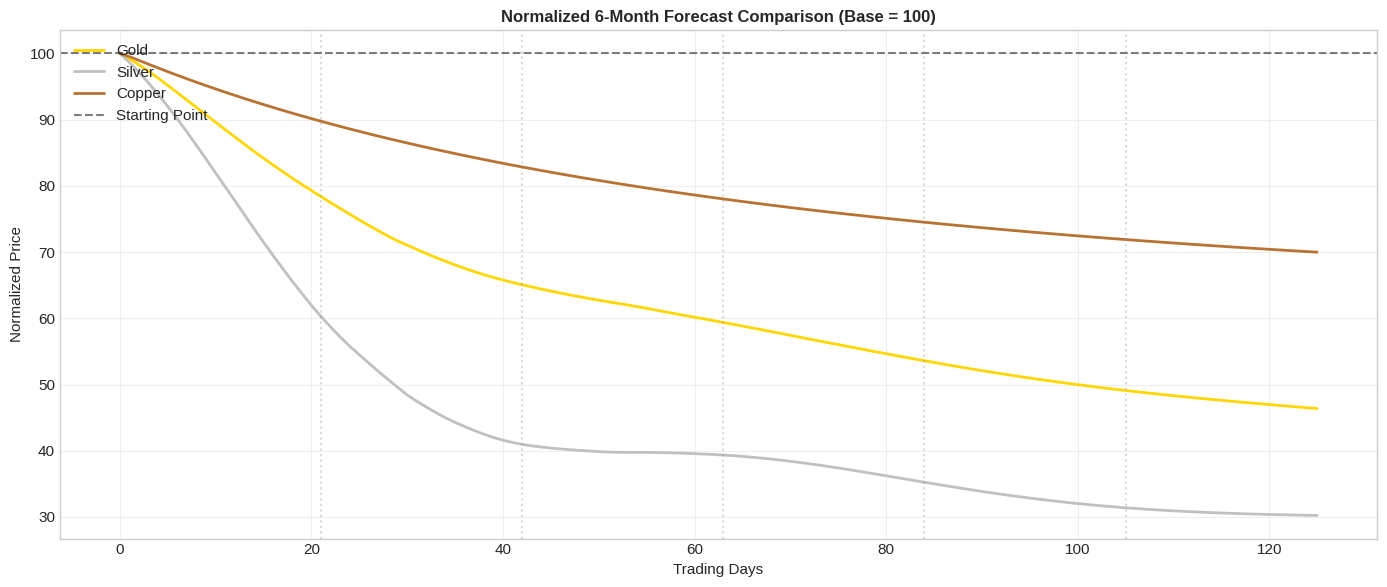

In [ ]:
# Normalized forecast comparison
fig, ax = plt.subplots(figsize=(14, 6))

for metal_name in metal_data.keys():
    # Normalize forecasts to start at 100
    predictions = forecasts[metal_name]['predictions'].flatten()
    normalized = (predictions / predictions[0]) * 100

    ax.plot(range(len(normalized)), normalized,
            label=metal_name, color=colors[metal_name], linewidth=2)

ax.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Starting Point')
ax.set_title('Normalized 6-Month Forecast Comparison (Base = 100)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Normalized Price')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add month markers
month_days = [21, 42, 63, 84, 105]
for day in month_days:
    ax.axvline(x=day, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

## 8.6 Export Forecast Data

In [ ]:
# Create detailed forecast DataFrame for export
forecast_export = pd.DataFrame()

for metal_name in metal_data.keys():
    metal_forecast = pd.DataFrame({
        'Date': forecasts[metal_name]['dates'],
        f'{metal_name}_Price': forecasts[metal_name]['predictions'].flatten()
    })

    if forecast_export.empty:
        forecast_export = metal_forecast
    else:
        forecast_export = forecast_export.merge(metal_forecast, on='Date')

print("6-Month Forecast Data (First 10 Days):")
print(forecast_export.head(10).to_string(index=False))

print("\n6-Month Forecast Data (Last 10 Days):")
print(forecast_export.tail(10).to_string(index=False))

6-Month Forecast Data (First 10 Days):
      Date  Gold_Price  Silver_Price  Copper_Price
2026-03-16 4832.443848     80.929344      5.740213
2026-03-17 4793.177734     79.842407      5.712623
2026-03-18 4749.636230     78.627388      5.679907
2026-03-19 4702.379395     77.322716      5.646878
2026-03-20 4652.226562     75.931190      5.614403
2026-03-23 4600.096680     74.467392      5.582565
2026-03-24 4546.687988     72.934830      5.551355
2026-03-25 4492.696777     71.345993      5.520766
2026-03-26 4438.950195     69.694672      5.490794
2026-03-27 4384.806152     68.034935      5.461433

6-Month Forecast Data (Last 10 Days):
      Date  Gold_Price  Silver_Price  Copper_Price
2026-08-25 2294.321533     24.718943      4.063080
2026-08-26 2288.035400     24.680653      4.057727
2026-08-27 2281.856934     24.645203      4.052442
2026-08-28 2275.777832     24.612320      4.047222
2026-08-31 2269.788818     24.581770      4.042068
2026-09-01 2263.888916     24.553328      4.036978
2026

In [ ]:
# Save forecast to CSV
forecast_export.to_csv('metal_price_forecast_6months.csv', index=False)
print("Forecast data saved to 'metal_price_forecast_6months.csv'")

---

# 9. Conclusions and Recommendations
<a id='9-conclusions-and-recommendations'></a>

## 9.1 Key Findings Summary

In [ ]:
# Generate final summary
print("FINAL MODEL PERFORMANCE AND FORECAST SUMMARY")
print("=" * 70)
print("\nThis analysis compared four deep learning architectures for metal price")
print("forecasting: Simple RNN, LSTM, Bidirectional LSTM, and GRU.")
print(f"\nData Period: 2015-01-01 to {datetime.now().strftime('%Y-%m-%d')}")
print(f"Forecast Horizon: 6 months (126 trading days)")
print("\n" + "-" * 70)

for metal_name in metal_data.keys():
    print(f"\n{metal_name.upper()}:")
    print(f"  Best Model: {best_models[metal_name]}")

    best_results = all_results[metal_name][best_models[metal_name]]
    print(f"  Test RMSE: {best_results['metrics']['test_rmse']:.2f} USD")
    print(f"  Test MAE: {best_results['metrics']['test_mae']:.2f} USD")
    print(f"  Test MAPE: {best_results['metrics']['test_mape']:.2f}%")

    forecast_data = forecasts[metal_name]
    current = forecast_data['last_actual_price']
    final = forecast_data['predictions'][-1][0]
    pct = ((final - current) / current) * 100
    print(f"  6-Month Forecast: ${current:.2f} -> ${final:.2f} ({pct:+.1f}%)")

print("\n" + "=" * 70)
print("\nOVERALL BEST MODEL:")
overall_best = sorted_rankings[0]
print(f"  Model: {overall_best[0]}")
print(f"  Average Test RMSE: {overall_best[1]['avg_rmse']:.2f} USD")
print(f"  Average Test MAPE: {overall_best[1]['avg_mape']:.2f}%")

FINAL MODEL PERFORMANCE AND FORECAST SUMMARY

This analysis compared four deep learning architectures for metal price
forecasting: Simple RNN, LSTM, Bidirectional LSTM, and GRU.

Data Period: 2015-01-01 to 2026-03-13
Forecast Horizon: 6 months (126 trading days)

----------------------------------------------------------------------

GOLD:
  Best Model: BiLSTM
  Test RMSE: 187.93 USD
  Test MAE: 148.50 USD
  Test MAPE: 4.36%
  6-Month Forecast: $5115.80 -> $2241.07 (-56.2%)

SILVER:
  Best Model: BiLSTM
  Test RMSE: 3.44 USD
  Test MAE: 1.91 USD
  Test MAPE: 3.98%
  6-Month Forecast: $84.67 -> $24.46 (-71.1%)

COPPER:
  Best Model: GRU
  Test RMSE: 0.13 USD
  Test MAE: 0.09 USD
  Test MAPE: 1.86%
  6-Month Forecast: $5.82 -> $4.02 (-31.0%)


OVERALL BEST MODEL:
  Model: BiLSTM
  Average Test RMSE: 63.84 USD
  Average Test MAPE: 3.53%


## 9.2 Model Architecture Comparison

### Simple RNN
- Fastest training time
- Struggles with longer sequences due to vanishing gradient
- Suitable for short-term patterns

### LSTM
- Handles long-term dependencies effectively
- More parameters than GRU
- Good balance between performance and complexity

### Bidirectional LSTM
- Captures context from both directions
- Highest number of parameters
- May provide marginal improvement for time series

### GRU
- Simplified architecture compared to LSTM
- Faster training than LSTM
- Often comparable performance to LSTM

## 9.3 Forecast Interpretation

**Important Considerations:**

1. **Forecast Uncertainty:** Predictions further into the future carry higher uncertainty. The 6-month forecasts should be viewed as trend indicators rather than precise price targets.

2. **Model Limitations:** The models are trained on historical price patterns and do not account for:
   - Geopolitical events
   - Economic policy changes
   - Supply disruptions
   - Market sentiment shifts

3. **Recursive Forecasting:** Since each prediction builds on previous predictions, errors can compound over time.

## 9.4 Business Recommendations

**For Trading Decisions:**
1. Use short-term forecasts (1-2 months) with higher confidence
2. Combine model predictions with fundamental analysis
3. Set appropriate stop-loss levels based on historical volatility

**For Risk Management:**
1. Account for prediction uncertainty using MAPE as a confidence measure
2. Consider ensemble methods for more robust predictions
3. Regularly retrain models with new data

**For Strategic Planning:**
1. Use 6-month forecasts for directional guidance, not precise targets
2. Consider multiple scenarios based on forecast range (min/max)
3. Monitor actual prices against forecasts and adjust strategies accordingly

## 9.5 Future Improvements

1. **Feature Engineering:** Add technical indicators (RSI, MACD, Moving Averages)
2. **External Data:** Incorporate macroeconomic indicators, USD index, inflation data
3. **Ensemble Methods:** Combine predictions from multiple models
4. **Attention Mechanisms:** Implement Transformer-based models
5. **Confidence Intervals:** Add prediction intervals using Monte Carlo dropout
6. **Hyperparameter Optimization:** Use grid search or Bayesian optimization

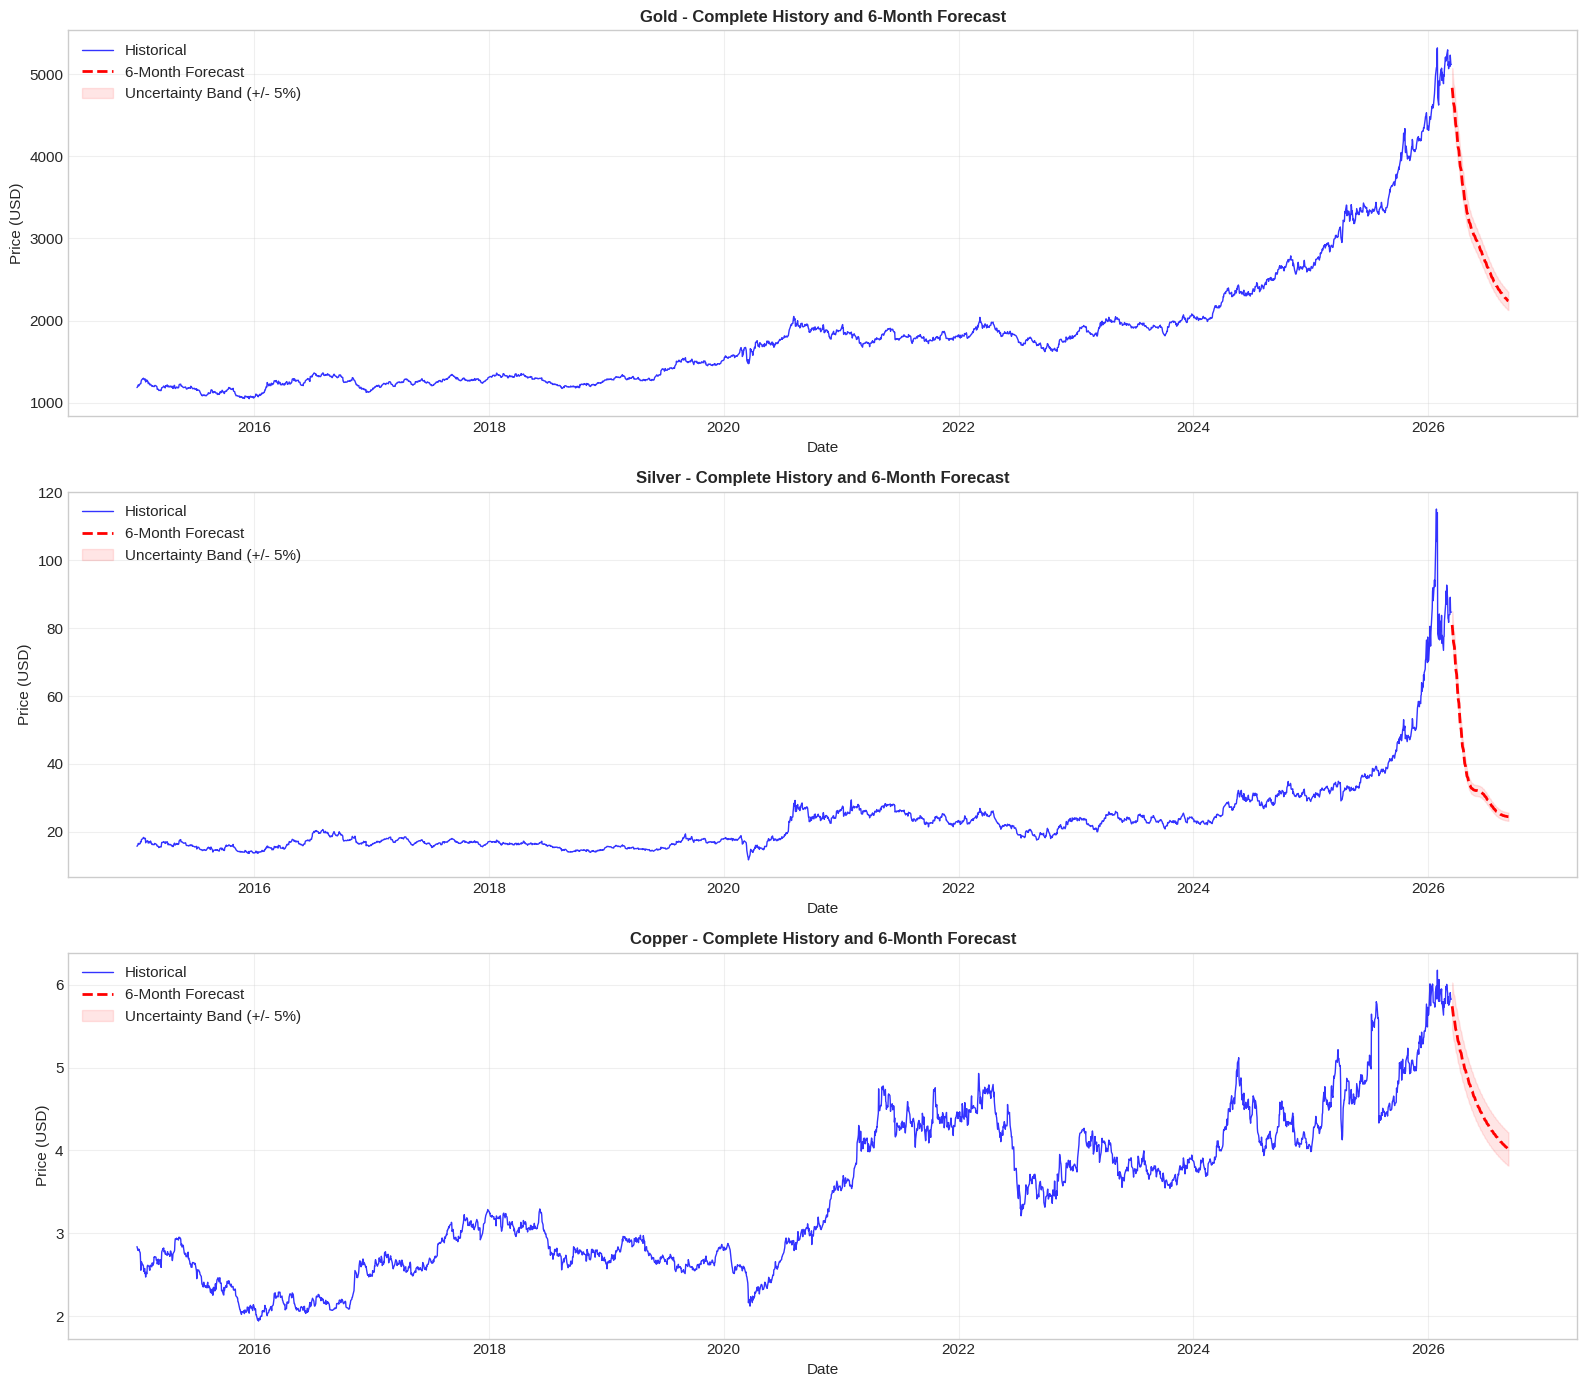

In [ ]:
# Final visualization - Combined historical and forecast
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for idx, metal_name in enumerate(metal_data.keys()):
    # Get all historical data
    historical_dates = prepared_data[metal_name]['dates']
    historical_prices = prepared_data[metal_name]['original']

    # Get forecast data
    forecast_dates = forecasts[metal_name]['dates']
    forecast_prices = forecasts[metal_name]['predictions']

    # Plot historical data
    axes[idx].plot(historical_dates, historical_prices,
                   color='blue', linewidth=1, label='Historical', alpha=0.8)

    # Plot forecast
    axes[idx].plot(forecast_dates, forecast_prices,
                   color='red', linewidth=2, linestyle='--', label='6-Month Forecast')

    # Shade forecast region
    axes[idx].fill_between(forecast_dates, forecast_prices.flatten() * 0.95,
                           forecast_prices.flatten() * 1.05,
                           color='red', alpha=0.1, label='Uncertainty Band (+/- 5%)')

    # Formatting
    axes[idx].set_title(f'{metal_name} - Complete History and 6-Month Forecast',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()